# MODULE 7 — Optimized 3-Class Subject-Independent EEG Pipeline

**Project:** Cross-dataset / within-dataset subject-independent motor-imagery EEG  
**Input contract:** 22 channels × 640 samples, 160 Hz, 8–30 Hz, 3 classes  
**Classes:** left / right / feet

This version is adapted from the previous Module 7 code to the **actual Module 5/6 cache interface**.

### Important protocol
- Primary evaluation is strict **within-dataset LOSO**.
- The held-out subject is never used for normalization fitting, feature selection, model selection, or training.
- Inner validation is performed only among source training subjects.
- No hard-coded `4 classes`, `1000 samples`, `9 subjects`, or `S0/S1` assumptions.
- The original GAN is optional and OFF by default; the default path prioritizes stable FBCSP + EEGNet fusion.

In [1]:
# ============================================================
# CELL 1 — IMPORTS + REPRODUCIBILITY + DEVICE
# ============================================================

from __future__ import annotations

import os
import gc
import json
import copy
import math
import time
import random
import warnings
from pathlib import Path
from typing import Optional, Iterable

import numpy as np
import pandas as pd
import h5py
import scipy.signal as sig
from scipy.linalg import eigh

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    log_loss,
)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)

print("Device:", device)

Device: mps


In [2]:
# ============================================================
# CELL 2 — AUTHORITATIVE PROJECT PATH DISCOVERY
# ============================================================
# The earlier modules define PROJECT_ROOT as:
#     /Users/ashokvarmabevara/Project2
#
# We preserve that path first, then provide safe fallbacks so
# the notebook can also run after the project directory has
# been moved/copied.

PROJECT_ROOT_CANDIDATES = [
    Path("/Users/ashokvarmabevara/Project2"),
    Path.cwd(),
    Path.home() / "Project2",
    Path("/mnt/data/Project2"),
]

PROJECT_ROOT = None

for candidate in PROJECT_ROOT_CANDIDATES:
    candidate = Path(candidate)
    if (
        (candidate / "cross_dataset_mi_project").exists()
        or (candidate / "BCI IV-2a").exists()
        or (candidate / "eegmmidb").exists()
    ):
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    # Last-resort explicit path from Modules 1–6.
    PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

OUTPUT_ROOT = PROJECT_ROOT / "cross_dataset_mi_project"
MANIFEST_ROOT = OUTPUT_ROOT / "manifests"
CACHE_ROOT = OUTPUT_ROOT / "cache"
RESULTS_ROOT = OUTPUT_ROOT / "results"
FIGURES_ROOT = OUTPUT_ROOT / "figures"
CHECKPOINT_ROOT = OUTPUT_ROOT / "checkpoints"

for p in [
    RESULTS_ROOT,
    FIGURES_ROOT,
    CHECKPOINT_ROOT,
]:
    p.mkdir(parents=True, exist_ok=True)

FINAL_CACHE_PATH = (
    CACHE_ROOT
    / "module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5"
)

MODULE_5_SPEC_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_preprocessing_specification.json"
)

MODULE_6_LOSO_PATH = (
    MANIFEST_ROOT
    / "module_6_within_dataset_loso_folds.csv"
)

MODULE_6_CACHE_META_PATH = (
    MANIFEST_ROOT
    / "module_6_cache_metadata.csv"
)

MODULE_6_PROTOCOL_PATH = (
    MANIFEST_ROOT
    / "module_6_baseline_protocol.json"
)

print("=" * 78)
print("MODULE 7 — PROJECT INTERFACE")
print("=" * 78)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Cache       :", FINAL_CACHE_PATH)
print("Manifest    :", MANIFEST_ROOT)
print("Results     :", RESULTS_ROOT)
print("Figures     :", FIGURES_ROOT)

print("\nExistence:")
for name, p in [
    ("PROJECT_ROOT", PROJECT_ROOT),
    ("OUTPUT_ROOT", OUTPUT_ROOT),
    ("FINAL_CACHE_PATH", FINAL_CACHE_PATH),
    ("MODULE_5_SPEC_PATH", MODULE_5_SPEC_PATH),
    ("MODULE_6_LOSO_PATH", MODULE_6_LOSO_PATH),
    ("MODULE_6_CACHE_META_PATH", MODULE_6_CACHE_META_PATH),
]:
    print(f"  {name:28s}: {'PASS' if p.exists() else 'FAIL'}")

MODULE 7 — PROJECT INTERFACE
PROJECT_ROOT: /Users/ashokvarmabevara/Project2
Cache       : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
Manifest    : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests
Results     : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/results
Figures     : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/figures

Existence:
  PROJECT_ROOT                : PASS
  OUTPUT_ROOT                 : PASS
  FINAL_CACHE_PATH            : PASS
  MODULE_5_SPEC_PATH          : PASS
  MODULE_6_LOSO_PATH          : PASS
  MODULE_6_CACHE_META_PATH    : PASS


In [3]:
# ============================================================
# CELL 3 — LOAD THE FROZEN MODULE 5/6 CONTRACT
# ============================================================

with open(MODULE_5_SPEC_PATH, "r", encoding="utf-8") as f:
    module_5_spec = json.load(f)

FROZEN_CHANNELS = [str(x) for x in module_5_spec["channels"]]
TARGET_SFREQ = float(module_5_spec["target_sfreq_hz"])
LOW_HZ, HIGH_HZ = map(float, module_5_spec["primary_bandpass_hz"])
N_SAMPLES = int(module_5_spec["epoch"]["n_samples"])
TMIN = float(module_5_spec["epoch"]["tmin_sec"])
TMAX = float(module_5_spec["epoch"]["tmax_sec"])

# Explicit 3-class project interface from Module 6.
CLASSES = ["left", "right", "feet"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
N_CLASSES = len(CLASSES)

print(json.dumps({
    "channels": FROZEN_CHANNELS,
    "n_channels": len(FROZEN_CHANNELS),
    "sampling_rate_hz": TARGET_SFREQ,
    "bandpass_hz": [LOW_HZ, HIGH_HZ],
    "epoch_sec": [TMIN, TMAX],
    "n_samples": N_SAMPLES,
    "classes": CLASS_TO_ID,
}, indent=2))

assert len(FROZEN_CHANNELS) == 22
assert TARGET_SFREQ == 160.0
assert (LOW_HZ, HIGH_HZ) == (8.0, 30.0)
assert N_SAMPLES == 640
assert abs((TMAX - TMIN) - 4.0) < 1e-9
assert N_CLASSES == 3

print("\nFrozen Module 5/6 interface: PASS")

{
  "channels": [
    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",
    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",
    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",
    "P1",
    "Pz",
    "P2",
    "POz"
  ],
  "n_channels": 22,
  "sampling_rate_hz": 160.0,
  "bandpass_hz": [
    8.0,
    30.0
  ],
  "epoch_sec": [
    0.0,
    4.0
  ],
  "n_samples": 640,
  "classes": {
    "left": 0,
    "right": 1,
    "feet": 2
  }
}

Frozen Module 5/6 interface: PASS


In [4]:
# ============================================================
# CELL 4 — LOAD + VERIFY FINAL HDF5 CACHE METADATA
# ============================================================

REQUIRED_META = [
    "dataset",
    "subject",
    "run",
    "recording_id",
    "filename",
    "absolute_path",
    "harmonized_class",
    "event_index",
    "onset_sec",
    "source_sfreq_hz",
]

def decode_strings(values):
    result = []
    for v in values:
        if isinstance(v, bytes):
            result.append(v.decode("utf-8"))
        else:
            result.append(str(v))
    return result

with h5py.File(FINAL_CACHE_PATH, "r") as h5:
    X_shape = tuple(h5["X"].shape)
    X_dtype = str(h5["X"].dtype)
    meta_keys = list(h5["metadata"].keys())

    missing = [k for k in REQUIRED_META if k not in meta_keys]
    cache_attrs = {k: h5.attrs[k] for k in h5.attrs.keys()}

    metadata = {}
    for key in [
        "dataset", "subject", "run", "recording_id",
        "filename", "absolute_path", "harmonized_class"
    ]:
        metadata[key] = decode_strings(h5["metadata"][key][:])

    metadata["event_index"] = h5["metadata"]["event_index"][:].astype(np.int64)
    metadata["onset_sec"] = h5["metadata"]["onset_sec"][:].astype(np.float64)
    metadata["source_sfreq_hz"] = h5["metadata"]["source_sfreq_hz"][:].astype(np.float64)

cache_meta_df = pd.DataFrame(metadata)
cache_meta_df.insert(0, "cache_index", np.arange(len(cache_meta_df), dtype=np.int64))

print("=" * 78)
print("CACHE CONTRACT")
print("=" * 78)
print("Shape :", X_shape)
print("Dtype :", X_dtype)
print("Epochs:", len(cache_meta_df))
print("Meta  :", meta_keys)

assert not missing, f"Missing metadata: {missing}"
assert X_shape[1:] == (22, 640)
assert X_dtype == "float32"
assert set(cache_meta_df["harmonized_class"].unique()) == set(CLASSES)
assert cache_meta_df["subject"].nunique() == 118

dataset_summary = (
    cache_meta_df
    .groupby(["dataset", "harmonized_class"])
    .size()
    .unstack(fill_value=0)
)

display(dataset_summary)

print("\n118-subject / 3-class / 22×640 cache contract: PASS")

CACHE CONTRACT
Shape : (9316, 22, 640)
Dtype : float32
Epochs: 9316
Meta  : ['absolute_path', 'dataset', 'event_index', 'filename', 'harmonized_class', 'onset_sec', 'recording_id', 'run', 'source_sfreq_hz', 'subject']


harmonized_class,feet,left,right
dataset,,,
BCI-IV-2a,648,648,648
EEGMMIDB,2455,2479,2438



118-subject / 3-class / 22×640 cache contract: PASS


In [7]:
# ============================================================
# CELL 5 — FIXED NUMERICAL QA + CACHE LOAD
# ============================================================
# Loads the authoritative Module-6 HDF5 cache first, then
# performs numerical QA.
#
# Module-6 cache:
#   X              -> EEG epochs
#   metadata       -> labels / subjects / dataset information
#
# Expected:
#   9316 epochs
#   22 channels
#   640 samples
#   118 subjects
#   3 classes
# ============================================================

import os
import json
import h5py
import numpy as np
import pandas as pd

print("=" * 72)
print("MODULE 7 — NUMERICAL QA + CACHE LOAD")
print("=" * 72)

# ------------------------------------------------------------
# 1. Locate project root
# ------------------------------------------------------------

from pathlib import Path

PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

# Allow execution from another machine/path if PROJECT_ROOT
# was already defined in an earlier notebook cell.
if "PROJECT_ROOT" in globals():
    PROJECT_ROOT = Path(PROJECT_ROOT)

PROJECT_DIR = PROJECT_ROOT / "cross_dataset_mi_project"
CACHE_ROOT = PROJECT_DIR / "cache"
MANIFEST_ROOT = PROJECT_DIR / "manifests"

FINAL_CACHE_PATH = (
    CACHE_ROOT /
    "module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5"
)

MODULE_5_SPEC_PATH = (
    MANIFEST_ROOT /
    "module_5_v2_preprocessing_specification.json"
)

CACHE_META_PATH = (
    MANIFEST_ROOT /
    "module_6_cache_metadata.csv"
)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nCache:")
print(FINAL_CACHE_PATH)

# ------------------------------------------------------------
# 2. Validate paths
# ------------------------------------------------------------

if not FINAL_CACHE_PATH.exists():
    raise FileNotFoundError(
        "\nModule-6 cache was not found:\n"
        f"{FINAL_CACHE_PATH}\n\n"
        "Check PROJECT_ROOT in this cell."
    )

print("\nCache exists: YES")

# ------------------------------------------------------------
# 3. Load Module-5 specification if available
# ------------------------------------------------------------

module_5_spec = {}

if MODULE_5_SPEC_PATH.exists():
    with open(MODULE_5_SPEC_PATH, "r") as f:
        module_5_spec = json.load(f)

print(
    "Module-5 specification:",
    "FOUND" if MODULE_5_SPEC_PATH.exists() else "NOT FOUND"
)

# ------------------------------------------------------------
# 4. Inspect HDF5 structure
# ------------------------------------------------------------

with h5py.File(FINAL_CACHE_PATH, "r") as h5:

    print("\nHDF5 datasets/groups:")

    def print_h5(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f"  {name:<35} "
                f"shape={obj.shape} "
                f"dtype={obj.dtype}"
            )
        else:
            print(f"  {name}/")

    h5.visititems(print_h5)

    assert "X" in h5, (
        "Authoritative cache does not contain dataset 'X'."
    )

    X_shape = tuple(h5["X"].shape)

print("\nCache X shape:", X_shape)

# ------------------------------------------------------------
# 5. Load EEG data
# ------------------------------------------------------------
# Module 6 defines the authoritative EEG array as h5["X"].
# Load it into RAM for Module 7.

with h5py.File(FINAL_CACHE_PATH, "r") as h5:
    X_raw = np.asarray(
        h5["X"][:],
        dtype=np.float32
    )

print(
    f"\nX_raw loaded successfully: "
    f"{X_raw.shape}, dtype={X_raw.dtype}"
)

# ------------------------------------------------------------
# 6. Load metadata
# ------------------------------------------------------------

if CACHE_META_PATH.exists():

    cache_meta_df = pd.read_csv(CACHE_META_PATH)

    print(
        "\nMetadata rows:",
        len(cache_meta_df)
    )

else:

    # Fall back to metadata stored inside HDF5.
    print(
        "\nWARNING: module_6_cache_metadata.csv not found."
    )

    with h5py.File(FINAL_CACHE_PATH, "r") as h5:

        assert "metadata" in h5, (
            "No CSV metadata and no HDF5 metadata group found."
        )

        metadata = {}

        for key in h5["metadata"].keys():

            arr = h5["metadata"][key][:]

            if arr.dtype.kind in {"S", "O"}:
                arr = np.array(
                    [
                        x.decode("utf-8")
                        if isinstance(x, bytes)
                        else str(x)
                        for x in arr
                    ]
                )

            metadata[key] = arr

    cache_meta_df = pd.DataFrame(metadata)

print("\nMetadata columns:")
print(cache_meta_df.columns.tolist())

# ------------------------------------------------------------
# 7. Resolve labels
# ------------------------------------------------------------

LABEL_CANDIDATES = [
    "label",
    "labels",
    "class",
    "harmonized_class",
]

label_col = None

for c in LABEL_CANDIDATES:
    if c in cache_meta_df.columns:
        label_col = c
        break

if label_col is None:
    raise KeyError(
        "Could not locate class labels in cache metadata.\n"
        f"Available columns: {cache_meta_df.columns.tolist()}"
    )

# Text class labels → integer labels
if cache_meta_df[label_col].dtype.kind in {"U", "S", "O"}:

    class_names = sorted(
        cache_meta_df[label_col]
        .astype(str)
        .unique()
        .tolist()
    )

    class_to_id = {
        name: i
        for i, name in enumerate(class_names)
    }

    y = (
        cache_meta_df[label_col]
        .astype(str)
        .map(class_to_id)
        .to_numpy(dtype=np.int64)
    )

    CLASSES = class_names

else:

    y = cache_meta_df[label_col].to_numpy(
        dtype=np.int64
    )

    unique_labels = sorted(
        np.unique(y).tolist()
    )

    # Preserve explicit class names when available.
    CLASSES = [str(x) for x in unique_labels]

print("\nLabel column:", label_col)
print("Classes:", CLASSES)
print("Encoded labels:", np.unique(y))

# ------------------------------------------------------------
# 8. Resolve subject IDs
# ------------------------------------------------------------

SUBJECT_CANDIDATES = [
    "subject",
    "subject_id",
    "subject_uid",
]

subject_col = None

for c in SUBJECT_CANDIDATES:
    if c in cache_meta_df.columns:
        subject_col = c
        break

if subject_col is None:
    raise KeyError(
        "Could not locate subject IDs in metadata.\n"
        f"Available columns: {cache_meta_df.columns.tolist()}"
    )

subjects = (
    cache_meta_df[subject_col]
    .astype(str)
    .to_numpy()
)

# ------------------------------------------------------------
# 9. Resolve dataset IDs
# ------------------------------------------------------------

DATASET_CANDIDATES = [
    "dataset",
    "dataset_name",
    "source_dataset",
]

dataset_col = None

for c in DATASET_CANDIDATES:
    if c in cache_meta_df.columns:
        dataset_col = c
        break

if dataset_col is not None:

    datasets = (
        cache_meta_df[dataset_col]
        .astype(str)
        .to_numpy()
    )

else:

    datasets = np.array(
        ["unknown"] * len(y),
        dtype=str
    )

# ------------------------------------------------------------
# 10. Basic consistency checks
# ------------------------------------------------------------

assert len(X_raw) == len(y), (
    f"X/y mismatch: {len(X_raw)} vs {len(y)}"
)

assert len(X_raw) == len(subjects), (
    f"X/subject mismatch: "
    f"{len(X_raw)} vs {len(subjects)}"
)

assert X_raw.ndim == 3, (
    f"Expected X=(N,C,T), got {X_raw.shape}"
)

N_EPOCHS, N_CHANNELS, N_SAMPLES = X_raw.shape

print("\nData interface:")
print(f"  epochs     : {N_EPOCHS}")
print(f"  channels   : {N_CHANNELS}")
print(f"  samples    : {N_SAMPLES}")
print(f"  classes    : {len(CLASSES)}")
print(f"  subjects   : {len(np.unique(subjects))}")

# ------------------------------------------------------------
# 11. Numerical QA
# ------------------------------------------------------------

nonfinite_mask = ~np.isfinite(X_raw)
nonfinite = int(nonfinite_mask.sum())

epoch_var = np.var(
    X_raw,
    axis=(1, 2)
)

zero_var_mask = epoch_var <= 1e-12
zero_var = int(zero_var_mask.sum())

print("\nNumerical QA:")
print(f"  Non-finite values   : {nonfinite}")
print(f"  Zero-variance epochs: {zero_var}")

# Non-finite values are a hard failure.
assert nonfinite == 0, (
    f"Found {nonfinite} non-finite values."
)

# Zero variance is a diagnostic condition, NOT an assertion.
print(
    "\nNumerical QA: PASS"
)

print(
    f"Zero-variance epochs retained in frozen cache: "
    f"{zero_var}"
)

# ------------------------------------------------------------
# 12. Dataset statistics
# ------------------------------------------------------------

print("\nClass distribution:")

class_counts = pd.Series(
    y
).value_counts().sort_index()

for cls_id, count in class_counts.items():

    cls_name = (
        CLASSES[int(cls_id)]
        if int(cls_id) < len(CLASSES)
        else str(cls_id)
    )

    print(
        f"  {cls_id} ({cls_name}): {count}"
    )

# ------------------------------------------------------------
# 13. Subject statistics
# ------------------------------------------------------------

subject_dataset = pd.DataFrame({
    "subject": subjects,
    "dataset": datasets,
})

subject_dataset["epochs"] = 1

subject_dataset = (
    subject_dataset
    .groupby(
        ["dataset", "subject"],
        as_index=False
    )["epochs"]
    .sum()
)

print("\nDataset / subject epoch statistics:")

display(
    subject_dataset.groupby("dataset")["epochs"]
    .agg(
        subjects="count",
        min_epochs="min",
        median_epochs="median",
        mean_epochs="mean",
        max_epochs="max",
    )
    .reset_index()
)

# ------------------------------------------------------------
# 14. Store zero-variance indices
# ------------------------------------------------------------

ZERO_VAR_INDICES = np.flatnonzero(
    zero_var_mask
).astype(np.int64)

ZERO_VAR_MASK = zero_var_mask

print(
    "\nZERO_VAR_INDICES:",
    len(ZERO_VAR_INDICES)
)

# ------------------------------------------------------------
# 15. Final interface summary
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("MODULE 7 DATA INTERFACE READY")
print("=" * 72)

print(f"Cache      : {FINAL_CACHE_PATH}")
print(f"X_raw      : {X_raw.shape}")
print(f"Labels     : {y.shape}")
print(f"Subjects   : {subjects.shape}")
print(f"Datasets   : {datasets.shape}")
print(f"Classes    : {CLASSES}")
print(f"Zero-var   : {zero_var}")
print(f"Nonfinite  : {nonfinite}")

print("\n✅ Cell 5 completed successfully.")

MODULE 7 — NUMERICAL QA + CACHE LOAD

Project root:
/Users/ashokvarmabevara/Project2

Cache:
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5

Cache exists: YES
Module-5 specification: FOUND

HDF5 datasets/groups:
  X                                   shape=(9316, 22, 640) dtype=float32
  metadata/
  metadata/absolute_path              shape=(9316,) dtype=object
  metadata/dataset                    shape=(9316,) dtype=object
  metadata/event_index                shape=(9316,) dtype=int64
  metadata/filename                   shape=(9316,) dtype=object
  metadata/harmonized_class           shape=(9316,) dtype=object
  metadata/onset_sec                  shape=(9316,) dtype=float64
  metadata/recording_id               shape=(9316,) dtype=object
  metadata/run                        shape=(9316,) dtype=object
  metadata/source_sfreq_hz            shape=(9316,) dtype=float64
  metadata/subject                    sh

,dataset,subjects,min_epochs,median_epochs,mean_epochs,max_epochs
0,BCI-IV-2a,9,216,216.0,216.000000,216
1,EEGMMIDB,109,54,68.0,67.633028,85



ZERO_VAR_INDICES: 0

MODULE 7 DATA INTERFACE READY
Cache      : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
X_raw      : (9316, 22, 640)
Labels     : (9316,)
Subjects   : (9316,)
Datasets   : (9316,)
Classes    : ['feet', 'left', 'right']
Zero-var   : 0
Nonfinite  : 0

✅ Cell 5 completed successfully.


In [8]:
# ============================================================
# CELL 6 — LEAKAGE-SAFE SOURCE-ONLY ROBUST NORMALIZATION
# ============================================================

class SourceOnlyRobustNormalizer:
    def __init__(self, eps=1e-6):
        self.eps = float(eps)
        self.median_ = None
        self.iqr_ = None
        self.fitted_subjects_ = tuple()

    def fit(self, X_source, source_subjects):
        X_source = np.asarray(X_source, dtype=np.float64)
        source_subjects = [str(s) for s in source_subjects]

        if X_source.ndim != 3 or X_source.shape[1:] != (22, 640):
            raise ValueError(f"Expected (N,22,640), got {X_source.shape}")

        values = X_source.transpose(1, 0, 2).reshape(22, -1)

        self.median_ = np.median(values, axis=1)
        q25 = np.percentile(values, 25, axis=1)
        q75 = np.percentile(values, 75, axis=1)
        self.iqr_ = np.maximum(q75 - q25, self.eps)

        self.fitted_subjects_ = tuple(sorted(set(source_subjects)))
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return (
            (X - self.median_[None, :, None])
            / (self.iqr_[None, :, None] + self.eps)
        ).astype(np.float32)

    def assert_target_excluded(self, target_subject):
        if str(target_subject) in set(self.fitted_subjects_):
            raise AssertionError(
                f"LEAKAGE: {target_subject} was used for normalization."
            )

print("Normalizer: ready")

Normalizer: ready


In [9]:
# ============================================================
# CELL 7 — HDF5 RANDOM-ACCESS HELPERS
# ============================================================

class HDF5EpochStore:
    def __init__(self, path):
        self.path = Path(path)
        self._h5 = None

    def __enter__(self):
        self._h5 = h5py.File(self.path, "r")
        return self

    def __exit__(self, exc_type, exc, tb):
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None

    @property
    def shape(self):
        return tuple(self._h5["X"].shape)

    def get_X(self, indices):
        indices = np.asarray(indices, dtype=np.int64)
        order = np.argsort(indices)
        sorted_idx = indices[order]
        values = np.asarray(self._h5["X"][sorted_idx], dtype=np.float32)
        return values[np.argsort(order)]

def load_indices(indices):
    with HDF5EpochStore(FINAL_CACHE_PATH) as store:
        return store.get_X(indices)

print("HDF5 loader:", load_indices([0, 1]).shape)

HDF5 loader: (2, 22, 640)


In [10]:
# ============================================================
# CELL 8 — SUBJECT-WISE FOLDS + INNER VALIDATION
# ============================================================

def parse_json_indices(s):
    return np.asarray(json.loads(s), dtype=np.int64)

# Prefer Module 6's authoritative LOSO manifest when available.
if MODULE_6_LOSO_PATH.exists():
    within_loso_df = pd.read_csv(MODULE_6_LOSO_PATH)
else:
    rows = []
    for dataset_name in sorted(cache_meta_df["dataset"].unique()):
        ds = cache_meta_df[cache_meta_df["dataset"] == dataset_name]
        for fold_id, target_subject in enumerate(sorted(ds["subject"].unique())):
            train_idx = ds.loc[ds["subject"] != target_subject, "cache_index"].tolist()
            test_idx = ds.loc[ds["subject"] == target_subject, "cache_index"].tolist()
            rows.append({
                "protocol": "within_dataset_loso",
                "dataset": dataset_name,
                "fold_id": fold_id,
                "target_subject": target_subject,
                "train_indices_json": json.dumps(train_idx),
                "test_indices_json": json.dumps(test_idx),
            })
    within_loso_df = pd.DataFrame(rows)

# Normalize manifest column naming across versions.
if "target_subject" not in within_loso_df.columns:
    raise RuntimeError("Module 6 LOSO manifest has no target_subject column.")

print("Within-dataset folds:", len(within_loso_df))
display(within_loso_df[[
    "dataset", "fold_id", "target_subject",
    "source_train_subject_count" if "source_train_subject_count" in within_loso_df.columns else "target_subject"
]].head())

def make_inner_subject_split(train_subjects, seed=SEED, val_fraction=0.20):
    subjects = np.array(sorted(set(map(str, train_subjects))))
    rng = np.random.default_rng(seed)
    rng.shuffle(subjects)

    n_val = max(1, int(round(len(subjects) * val_fraction)))
    n_val = min(n_val, len(subjects) - 1)

    return set(subjects[n_val:]), set(subjects[:n_val])

def make_balanced_sample_weights(y):
    y = np.asarray(y, dtype=np.int64)
    counts = np.bincount(y, minlength=N_CLASSES).astype(np.float64)
    weights = np.zeros_like(counts)
    weights[counts > 0] = 1.0 / counts[counts > 0]
    return weights[y]

print("Inner validation splitter: ready")

Within-dataset folds: 118


,dataset,fold_id,target_subject,source_train_subject_count
0,BCI-IV-2a,0,S01,8
1,BCI-IV-2a,1,S02,8
2,BCI-IV-2a,2,S03,8
3,BCI-IV-2a,3,S04,8
4,BCI-IV-2a,4,S05,8


Inner validation splitter: ready


In [11]:
# ============================================================
# CELL 9 — EEG AUGMENTATION FOR SOURCE TRAINING
# ============================================================

def augment_eeg_batch(
    xb,
    p_noise=0.35,
    p_scale=0.45,
    p_shift=0.35,
    p_channel_drop=0.15,
):
    # xb: [B,C,T]
    out = xb

    if torch.rand(1, device=xb.device).item() < p_scale:
        scale = torch.empty(
            xb.size(0), 1, 1, device=xb.device
        ).uniform_(0.85, 1.15)
        out = out * scale

    if torch.rand(1, device=xb.device).item() < p_noise:
        noise = 0.02 * torch.randn_like(out)
        out = out + noise

    if torch.rand(1, device=xb.device).item() < p_shift:
        max_shift = max(1, int(0.08 * xb.size(-1)))
        shift = int(
            torch.randint(
                -max_shift,
                max_shift + 1,
                (1,),
                device=xb.device,
            ).item()
        )
        if shift != 0:
            out = torch.roll(out, shifts=shift, dims=-1)

    if torch.rand(1, device=xb.device).item() < p_channel_drop:
        mask = torch.ones(
            xb.size(0), xb.size(1), 1,
            device=xb.device
        )
        n_drop = max(1, int(round(0.05 * xb.size(1))))
        for b in range(xb.size(0)):
            idx = torch.randperm(xb.size(1), device=xb.device)[:n_drop]
            mask[b, idx, :] = 0.0
        out = out * mask

    return out

print("EEG augmentation: ready")

EEG augmentation: ready


In [33]:
# ============================================================
# CELL 10 — SUBJECT-INVARIANT EEGNET + DOMAIN ADVERSARIAL HEAD
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy
import numpy as np


class GradientReversalFunction(
    torch.autograd.Function
):
    @staticmethod
    def forward(
        ctx,
        x,
        lambd,
    ):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(
        ctx,
        grad_output,
    ):
        return (
            -ctx.lambd * grad_output,
            None,
        )


class GradientReversal(
    nn.Module
):
    def forward(
        self,
        x,
        lambd=1.0,
    ):
        return GradientReversalFunction.apply(
            x,
            lambd,
        )


class SubjectInvariantEEGNet(
    nn.Module
):

    def __init__(
        self,
        n_ch=22,
        n_t=640,
        n_cls=3,
        n_domains=8,
        F1=12,
        D=2,
        F2=24,
        embedding_dim=128,
        dropout=0.35,
    ):

        super().__init__()

        # ----------------------------------------------------
        # Input normalization
        # ----------------------------------------------------

        self.input_norm = nn.InstanceNorm2d(
            1,
            affine=False,
            track_running_stats=False,
        )

        # ----------------------------------------------------
        # Multi-scale temporal convolutions
        # ----------------------------------------------------

        self.t15 = nn.Sequential(
            nn.Conv2d(
                1,
                F1,
                (1, 15),
                padding=(0, 7),
                bias=False,
            ),
            nn.GroupNorm(
                4,
                F1,
            ),
            nn.ELU(),
        )

        self.t31 = nn.Sequential(
            nn.Conv2d(
                1,
                F1,
                (1, 31),
                padding=(0, 15),
                bias=False,
            ),
            nn.GroupNorm(
                4,
                F1,
            ),
            nn.ELU(),
        )

        self.t63 = nn.Sequential(
            nn.Conv2d(
                1,
                F1,
                (1, 63),
                padding=(0, 31),
                bias=False,
            ),
            nn.GroupNorm(
                4,
                F1,
            ),
            nn.ELU(),
        )

        # ----------------------------------------------------
        # Multi-scale fusion
        # ----------------------------------------------------

        self.scale_fusion = nn.Sequential(
            nn.Conv2d(
                3 * F1,
                F1,
                (1, 1),
                bias=False,
            ),
            nn.GroupNorm(
                4,
                F1,
            ),
            nn.ELU(),
        )

        # ----------------------------------------------------
        # Depthwise spatial filtering
        # ----------------------------------------------------

        self.spatial = nn.Sequential(
            nn.Conv2d(
                F1,
                F1 * D,
                (n_ch, 1),
                groups=F1,
                bias=False,
            ),
            nn.GroupNorm(
                6,
                F1 * D,
            ),
            nn.ELU(),

            nn.AvgPool2d(
                (1, 4)
            ),

            nn.Dropout(
                dropout
            ),
        )

        # ----------------------------------------------------
        # Separable temporal block
        # ----------------------------------------------------

        self.separable = nn.Sequential(
            nn.Conv2d(
                F1 * D,
                F1 * D,
                (1, 15),
                padding=(0, 7),
                groups=F1 * D,
                bias=False,
            ),

            nn.Conv2d(
                F1 * D,
                F2,
                (1, 1),
                bias=False,
            ),

            nn.GroupNorm(
                6,
                F2,
            ),

            nn.ELU(),

            nn.AvgPool2d(
                (1, 8)
            ),

            nn.Dropout(
                dropout
            ),
        )

        # ----------------------------------------------------
        # Determine flatten dimension
        # ----------------------------------------------------

        with torch.no_grad():

            dummy = torch.zeros(
                2,
                1,
                n_ch,
                n_t,
            )

            z = self._features(
                dummy
            )

            flat_dim = z.flatten(
                1
            ).shape[1]

        # ----------------------------------------------------
        # Compact invariant representation
        # ----------------------------------------------------

        self.embedding = nn.Sequential(
            nn.Linear(
                flat_dim,
                embedding_dim,
            ),

            nn.LayerNorm(
                embedding_dim
            ),

            nn.ELU(),

            nn.Dropout(
                0.20
            ),
        )

        # ----------------------------------------------------
        # Classification head
        # ----------------------------------------------------

        self.classifier = nn.Linear(
            embedding_dim,
            n_cls,
        )

        # ----------------------------------------------------
        # Domain discriminator
        #
        # Domain IDs correspond to source subjects.
        # ----------------------------------------------------

        self.domain_head = nn.Sequential(
            nn.Linear(
                embedding_dim,
                64,
            ),

            nn.ReLU(),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                64,
                n_domains,
            ),
        )

        self.grl = GradientReversal()

        self.feature_dim = embedding_dim

    def _features(
        self,
        x,
    ):

        x = self.input_norm(
            x
        )

        z1 = self.t15(
            x
        )

        z2 = self.t31(
            x
        )

        z3 = self.t63(
            x
        )

        z = torch.cat(
            [
                z1,
                z2,
                z3,
            ],
            dim=1,
        )

        z = self.scale_fusion(
            z
        )

        z = self.spatial(
            z
        )

        z = self.separable(
            z
        )

        return z

    def forward(
        self,
        x,
        domain_lambda=0.0,
    ):

        # x = (B,C,T)
        x = x.unsqueeze(
            1
        )

        z = self._features(
            x
        )

        z = z.flatten(
            1
        )

        feat = self.embedding(
            z
        )

        class_logits = self.classifier(
            feat
        )

        if domain_lambda > 0:

            reversed_feat = self.grl(
                feat,
                domain_lambda,
            )

            domain_logits = (
                self.domain_head(
                    reversed_feat
                )
            )

        else:

            domain_logits = None

        return (
            class_logits,
            feat,
            domain_logits,
        )


_test = SubjectInvariantEEGNet(
    n_ch=22,
    n_t=640,
    n_cls=N_CLASSES,
    n_domains=8,
)

print(
    "Subject-invariant EEGNet ready"
)

print(
    "Embedding dimension:",
    _test.feature_dim,
)

Subject-invariant EEGNet ready
Embedding dimension: 128


In [34]:
# ============================================================
# CELL 11 — DOMAIN-ADVERSARIAL EEGNET TRAINING
# ============================================================

def make_subject_domain_labels(
    subjects,
):
    """
    Convert source subject IDs to consecutive domain IDs.
    """

    subjects = np.asarray(
        subjects
    ).astype(str)

    unique = sorted(
        np.unique(
            subjects
        )
    )

    mapping = {
        s: i
        for i, s in enumerate(
            unique
        )
    }

    domain_ids = np.asarray(
        [
            mapping[s]
            for s in subjects
        ],
        dtype=np.int64,
    )

    return (
        domain_ids,
        mapping,
    )


@torch.no_grad()
def predict_proba_torch(
    model,
    X,
    temperature=1.0,
):

    model.eval()

    ds = torch.utils.data.TensorDataset(
        torch.from_numpy(
            np.asarray(
                X,
                dtype=np.float32,
            )
        ),
        torch.zeros(
            len(X),
            dtype=torch.long,
        ),
    )

    loader = DataLoader(
        ds,
        batch_size=128,
        shuffle=False,
    )

    logits_all = []

    for xb, _ in loader:

        xb = xb.to(
            device
        )

        output = model(
            xb,
            domain_lambda=0.0,
        )

        logits = output[0]

        logits_all.append(
            logits.cpu().numpy()
        )

    logits = np.vstack(
        logits_all
    )

    logits /= max(
        float(temperature),
        1e-6,
    )

    logits -= logits.max(
        axis=1,
        keepdims=True,
    )

    P = np.exp(
        logits
    )

    P /= (
        P.sum(
            axis=1,
            keepdims=True,
        )
        + 1e-12
    )

    return P


def train_eegnet(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=120,
    batch_size=64,
    lr=5e-4,
    patience=25,
):

    # ========================================================
    # DOMAIN LABELS
    #
    # We do not have a subject array in the function signature,
    # so derive domains from the current source-train ordering
    # through the global fold helper when available.
    # ========================================================

    if (
        "CURRENT_TRAIN_SUBJECTS"
        not in globals()
    ):

        raise RuntimeError(
            "CURRENT_TRAIN_SUBJECTS is required "
            "for domain-adversarial training."
        )

    train_subjects = np.asarray(
        CURRENT_TRAIN_SUBJECTS
    ).astype(str)

    if len(train_subjects) != len(
        y_train
    ):

        raise ValueError(
            "CURRENT_TRAIN_SUBJECTS length "
            "does not match X_train."
        )

    domain_y, domain_mapping = (
        make_subject_domain_labels(
            train_subjects
        )
    )

    n_domains = len(
        domain_mapping
    )

    model = SubjectInvariantEEGNet(
        n_ch=X_train.shape[1],
        n_t=X_train.shape[2],
        n_cls=N_CLASSES,
        n_domains=n_domains,
        F1=12,
        D=2,
        F2=24,
        embedding_dim=128,
        dropout=0.35,
    ).to(device)

    # --------------------------------------------------------
    # Classification loss
    # --------------------------------------------------------

    counts = np.bincount(
        y_train,
        minlength=N_CLASSES,
    ).astype(
        np.float32
    )

    class_weights = (
        counts.sum()
        / (
            N_CLASSES
            * np.maximum(
                counts,
                1.0,
            )
        )
    )

    class_weights /= (
        class_weights.mean()
        + 1e-12
    )

    class_weights = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=device,
    )

    class_loss = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.02,
    )

    # --------------------------------------------------------
    # Domain loss
    # --------------------------------------------------------

    domain_loss = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=3e-4,
    )

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=20,
        T_mult=2,
        eta_min=2e-6,
    )

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    train_ds = torch.utils.data.TensorDataset(
        torch.from_numpy(
            np.asarray(
                X_train,
                dtype=np.float32,
            )
        ),
        torch.from_numpy(
            np.asarray(
                y_train,
                dtype=np.int64,
            )
        ),
        torch.from_numpy(
            domain_y,
        ),
    )

    sample_weights = make_balanced_sample_weights(
        y_train
    )

    sampler = WeightedRandomSampler(
        torch.as_tensor(
            sample_weights,
            dtype=torch.double,
        ),
        num_samples=len(
            y_train
        ),
        replacement=True,
    )

    loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        drop_last=False,
    )

    # --------------------------------------------------------
    # Best checkpoint
    # --------------------------------------------------------

    best_state = None
    best_val = -np.inf
    best_epoch = 0
    wait = 0

    history = []

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for epoch in range(
        1,
        epochs + 1,
    ):

        model.train()

        train_pred = []
        train_true = []

        loss_values = []

        # Gradually increase domain pressure.
        progress = (
            epoch / max(
                1,
                epochs,
            )
        )

        domain_lambda = (
            0.15
            * (
                2.0
                /
                (
                    1.0
                    + np.exp(
                        -8.0 * progress
                    )
                )
                - 1.0
            )
        )

        for xb, yb, db in loader:

            xb = xb.to(
                device
            )

            yb = yb.to(
                device
            )

            db = db.to(
                device
            )

            xb_aug = (
                augment_subject_invariant(
                    xb
                )
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            class_logits, feat, domain_logits = (
                model(
                    xb_aug,
                    domain_lambda=domain_lambda,
                )
            )

            loss_cls = (
                class_loss(
                    class_logits,
                    yb,
                )
            )

            loss_dom = (
                domain_loss(
                    domain_logits,
                    db,
                )
            )

            # Classification remains dominant.
            loss = (
                loss_cls
                + domain_lambda
                * loss_dom
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
            )

            optimizer.step()

            loss_values.append(
                float(
                    loss.item()
                )
            )

            train_pred.extend(
                class_logits.argmax(
                    1
                )
                .detach()
                .cpu()
                .numpy()
            )

            train_true.extend(
                yb.detach()
                .cpu()
                .numpy()
            )

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        P_val = predict_proba_torch(
            model,
            X_val,
        )

        val_pred = (
            P_val.argmax(
                1
            )
        )

        train_acc = (
            accuracy_score(
                train_true,
                train_pred,
            )
            * 100
        )

        val_acc = (
            accuracy_score(
                y_val,
                val_pred,
            )
            * 100
        )

        val_bacc = (
            balanced_accuracy_score(
                y_val,
                val_pred,
            )
            * 100
        )

        history.append(
            {
                "epoch": epoch,
                "train_acc": train_acc,
                "val_acc": val_acc,
                "val_bacc": val_bacc,
                "loss": np.mean(
                    loss_values
                ),
                "domain_lambda":
                    domain_lambda,
            }
        )

        scheduler.step(
            epoch
        )

        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if val_bacc > best_val:

            best_val = val_bacc
            best_epoch = epoch
            wait = 0

            best_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            wait += 1

        if (
            epoch == 1
            or epoch % 10 == 0
        ):

            print(
                f"    epoch {epoch:03d} | "
                f"train={train_acc:5.1f}% | "
                f"val={val_acc:5.1f}% | "
                f"bAcc={val_bacc:5.1f}% | "
                f"λ={domain_lambda:.3f}"
            )

        if wait >= patience:

            print(
                f"    Early stop epoch={epoch}; "
                f"best={best_epoch}"
            )

            break

    # --------------------------------------------------------
    # Restore best source-validation checkpoint.
    # --------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    history_df = pd.DataFrame(
        history
    )

    print(
        f"    Best validation bAcc: "
        f"{best_val:.2f}% "
        f"(epoch {best_epoch})"
    )

    return (
        model,
        history_df,
    )


print(
    "Domain-adversarial EEGNet trainer ready."
)

Domain-adversarial EEGNet trainer ready.


In [35]:
# ============================================================
# CELL 12 — MULTI-BAND FBCSP + REGULARIZED LDA
# FIXED CSP DIMENSION ORDER
# ============================================================

FBCSP_BANDS = [
    (8, 12),
    (10, 14),
    (12, 16),
    (14, 18),
    (16, 20),
    (18, 24),
    (20, 28),
    (8, 16),
    (16, 30),
]

N_CSP_COMP = 2
CSP_REG = 1e-5


def butter_bandpass(X, lo, hi, fs=TARGET_SFREQ, order=4):
    X = np.asarray(X, dtype=np.float32)

    nyq = fs / 2.0

    b, a = sig.butter(
        order,
        [lo / nyq, hi / nyq],
        btype="band",
    )

    return sig.filtfilt(
        b,
        a,
        X,
        axis=-1,
    ).astype(np.float32)


def normalized_cov(trials):
    """
    Mean normalized covariance.

    Input:
        trials = (N, C, T)

    Output:
        R = (C, C)
    """

    trials = np.asarray(trials, dtype=np.float64)

    if trials.ndim != 3:
        raise ValueError(
            f"Expected (N,C,T), got {trials.shape}"
        )

    covs = []

    for trial in trials:

        trial = trial - trial.mean(
            axis=1,
            keepdims=True,
        )

        C = trial @ trial.T

        trace = np.trace(C)

        if not np.isfinite(trace) or trace <= 1e-12:
            continue

        C = C / trace

        covs.append(C)

    if len(covs) == 0:
        raise ValueError(
            "No valid non-zero covariance matrices."
        )

    return np.mean(covs, axis=0)


def solve_csp_binary(
    Xa,
    Xb,
    n_comp=N_CSP_COMP,
):
    """
    Solve regularized binary CSP.

    Returns:
        W: (n_channels, 2*n_comp)

    IMPORTANT:
        Columns of W are spatial filters.
        Projection is therefore:

            W.T @ X

        which is implemented in csp_features_from_filters().
    """

    if len(Xa) == 0 or len(Xb) == 0:
        raise ValueError(
            f"Empty CSP class: Xa={len(Xa)}, Xb={len(Xb)}"
        )

    Ra = normalized_cov(Xa)
    Rb = normalized_cov(Xb)

    n_ch = Ra.shape[0]

    reg_scale = np.trace(
        Ra + Rb
    ) / max(n_ch, 1)

    reg = CSP_REG * max(
        reg_scale,
        1e-8,
    )

    I = np.eye(
        n_ch,
        dtype=np.float64,
    )

    vals, vecs = eigh(
        Ra + reg * I,
        Ra + Rb + 2.0 * reg * I,
    )

    vals = np.asarray(vals)

    # Highest generalized eigenvalues
    # and lowest generalized eigenvalues.
    order = np.argsort(vals)

    low = order[:n_comp]
    high = order[-n_comp:]

    keep = np.concatenate(
        [high, low]
    )

    W = vecs[:, keep]

    # Numerical safety.
    W = np.nan_to_num(
        W,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    return W.astype(np.float32)


def csp_features_from_filters(
    X,
    filters,
):
    """
    Correct CSP projection.

    X:
        (N, C, T)

    filters:
        (C, K)

    Projection:
        Z[n,k,t] = sum_c filters[c,k] * X[n,c,t]

    Therefore:
        'ck,nct->nkt'

    The previous implementation used:
        'kc,nct->nkt'

    which is dimensionally incorrect when filters=(22,K).
    """

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    filters = np.asarray(
        filters,
        dtype=np.float32,
    )

    if X.ndim != 3:
        raise ValueError(
            f"X must be (N,C,T), got {X.shape}"
        )

    if filters.ndim != 2:
        raise ValueError(
            f"filters must be (C,K), got {filters.shape}"
        )

    n, c, t = X.shape

    if filters.shape[0] != c:
        raise ValueError(
            "CSP channel mismatch:\n"
            f"  X channels       = {c}\n"
            f"  filter channels  = {filters.shape[0]}\n"
            f"  filter shape     = {filters.shape}"
        )

    # Correct spatial filtering.
    Z = np.einsum(
        "ck,nct->nkt",
        filters,
        X,
        optimize=True,
    )

    # Log-variance features.
    var = np.var(
        Z,
        axis=2,
    )

    var = np.maximum(
        var,
        1e-10,
    )

    feat = np.log(var)

    # Per-trial feature normalization.
    feat_mean = feat.mean(
        axis=1,
        keepdims=True,
    )

    feat_std = feat.std(
        axis=1,
        keepdims=True,
    )

    feat = (
        feat - feat_mean
    ) / (
        feat_std + 1e-8
    )

    return feat.astype(np.float32)


def fit_fbcsp_lda(
    X_train,
    y_train,
    X_val,
    X_test,
):
    """
    Multi-band one-vs-rest FBCSP.

    All CSP filters are learned exclusively from
    X_train/y_train.

    X_val and X_test are transformation-only.
    """

    X_train = np.asarray(
        X_train,
        dtype=np.float32,
    )

    X_val = np.asarray(
        X_val,
        dtype=np.float32,
    )

    X_test = np.asarray(
        X_test,
        dtype=np.float32,
    )

    y_train = np.asarray(
        y_train,
        dtype=np.int64,
    )

    if X_train.shape[1:] != (22, 640):
        raise ValueError(
            f"Expected training shape (N,22,640), "
            f"got {X_train.shape}"
        )

    feature_train = []
    feature_val = []
    feature_test = []

    filters_all = []

    for band_id, (lo, hi) in enumerate(
        FBCSP_BANDS
    ):

        print(
            f"      FBCSP band "
            f"{band_id + 1}/{len(FBCSP_BANDS)}: "
            f"{lo}-{hi} Hz",
            end=" ",
            flush=True,
        )

        Xtr_b = butter_bandpass(
            X_train,
            lo,
            hi,
        )

        Xv_b = butter_bandpass(
            X_val,
            lo,
            hi,
        )

        Xt_b = butter_bandpass(
            X_test,
            lo,
            hi,
        )

        band_filters = []

        band_train = []
        band_val = []
        band_test = []

        for cls in range(N_CLASSES):

            Xa = Xtr_b[
                y_train == cls
            ]

            Xb = Xtr_b[
                y_train != cls
            ]

            W = solve_csp_binary(
                Xa,
                Xb,
                n_comp=N_CSP_COMP,
            )

            band_filters.append(W)

            Ft = csp_features_from_filters(
                Xtr_b,
                W,
            )

            Fv = csp_features_from_filters(
                Xv_b,
                W,
            )

            Fte = csp_features_from_filters(
                Xt_b,
                W,
            )

            band_train.append(Ft)
            band_val.append(Fv)
            band_test.append(Fte)

        # All OVR CSP filters from this band.
        F_band_train = np.hstack(
            band_train
        )

        F_band_val = np.hstack(
            band_val
        )

        F_band_test = np.hstack(
            band_test
        )

        feature_train.append(
            F_band_train
        )

        feature_val.append(
            F_band_val
        )

        feature_test.append(
            F_band_test
        )

        filters_all.append(
            band_filters
        )

        print(
            f"features={F_band_train.shape[1]}"
        )

    Ftr = np.hstack(
        feature_train
    )

    Fv = np.hstack(
        feature_val
    )

    Ft = np.hstack(
        feature_test
    )

    # Remove numerical problems.
    Ftr = np.nan_to_num(
        Ftr,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    Fv = np.nan_to_num(
        Fv,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    Ft = np.nan_to_num(
        Ft,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    print(
        "\n      FBCSP feature shapes:"
    )

    print(
        "        train:",
        Ftr.shape
    )

    print(
        "        val  :",
        Fv.shape
    )

    print(
        "        test :",
        Ft.shape
    )

    # --------------------------------------------------------
    # Standardization fitted ONLY on source training data.
    # --------------------------------------------------------

    scaler = StandardScaler()

    Ftr_s = scaler.fit_transform(
        Ftr
    )

    Fv_s = scaler.transform(
        Fv
    )

    Ft_s = scaler.transform(
        Ft
    )

    # --------------------------------------------------------
    # Shrinkage LDA
    # --------------------------------------------------------

    lda = LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage="auto",
    )

    lda.fit(
        Ftr_s,
        y_train,
    )

    P_train = lda.predict_proba(
        Ftr_s
    )

    P_val = lda.predict_proba(
        Fv_s
    )

    P_test = lda.predict_proba(
        Ft_s
    )

    return {
        "F_train": Ftr_s,
        "F_val": Fv_s,
        "F_test": Ft_s,
        "P_train": P_train,
        "P_val": P_val,
        "P_test": P_test,
        "filters": filters_all,
        "scaler": scaler,
        "lda": lda,
    }


print(
    "\nFBCSP-LDA ready."
)

print(
    f"Bands       : {len(FBCSP_BANDS)}"
)

print(
    f"Classes     : {N_CLASSES}"
)

print(
    f"CSP filters : {2 * N_CSP_COMP} per class/band"
)


FBCSP-LDA ready.
Bands       : 9
Classes     : 3
CSP filters : 4 per class/band


In [36]:
# ============================================================
# CELL 13 — EEGNET-FIRST CALIBRATION + SIMPLE FUSION
# ============================================================

def temperature_from_validation(
    y_true,
    P_or_logits,
    is_logits=False,
):
    """
    Temperature calibration using SOURCE validation only.
    """

    y_true = np.asarray(
        y_true,
        dtype=np.int64,
    )

    if is_logits:
        logits = np.asarray(
            P_or_logits,
            dtype=np.float64,
        )
    else:
        P = np.asarray(
            P_or_logits,
            dtype=np.float64,
        )

        logits = np.log(
            np.clip(P, 1e-8, 1.0)
        )

    best_T = 1.0
    best_nll = np.inf

    for T in np.arange(
        0.70,
        2.51,
        0.05,
    ):

        z = logits / T
        z -= z.max(
            axis=1,
            keepdims=True,
        )

        p = np.exp(z)

        p /= (
            p.sum(
                axis=1,
                keepdims=True,
            )
            + 1e-12
        )

        nll = log_loss(
            y_true,
            p,
            labels=list(range(N_CLASSES)),
        )

        if nll < best_nll:
            best_nll = nll
            best_T = float(T)

    z = logits / best_T

    z -= z.max(
        axis=1,
        keepdims=True,
    )

    p = np.exp(z)

    p /= (
        p.sum(
            axis=1,
            keepdims=True,
        )
        + 1e-12
    )

    return best_T, p


def weighted_fusion(
    P_csp,
    P_net,
    alpha,
):

    P_csp = np.asarray(
        P_csp,
        dtype=np.float64,
    )

    P_net = np.asarray(
        P_net,
        dtype=np.float64,
    )

    alpha = float(alpha)

    # Confidence.
    conf_csp = np.max(
        P_csp,
        axis=1,
        keepdims=True,
    )

    conf_net = np.max(
        P_net,
        axis=1,
        keepdims=True,
    )

    w_csp = (
        alpha
        * conf_csp
        + 1e-8
    )

    w_net = (
        (1.0 - alpha)
        * conf_net
        + 1e-8
    )

    P = (
        w_csp * P_csp
        + w_net * P_net
    ) / (
        w_csp + w_net
    )

    return (
        P
        / (
            P.sum(
                axis=1,
                keepdims=True,
            )
            + 1e-12
        )
    )


def find_best_fusion_alpha(
    Pc_val,
    Pn_val,
    y_val,
):

    candidates = []

    # Explicitly include pure EEGNet.
    candidates.append(
        {
            "method": "EEGNET",
            "alpha": 0.0,
            "P": Pn_val,
        }
    )

    # Pure CSP.
    candidates.append(
        {
            "method": "CSP",
            "alpha": 1.0,
            "P": Pc_val,
        }
    )

    # Fusion candidates.
    for alpha in np.arange(
        0.10,
        0.95,
        0.05,
    ):

        P = weighted_fusion(
            Pc_val,
            Pn_val,
            alpha,
        )

        candidates.append(
            {
                "method": "FUSION",
                "alpha": float(alpha),
                "P": P,
            }
        )

    scored = []

    for item in candidates:

        pred = item["P"].argmax(
            axis=1
        )

        acc = (
            accuracy_score(
                y_val,
                pred,
            )
            * 100.0
        )

        bacc = (
            balanced_accuracy_score(
                y_val,
                pred,
            )
            * 100.0
        )

        scored.append(
            {
                "method": item["method"],
                "alpha": item["alpha"],
                "accuracy": acc,
                "bacc": bacc,
            }
        )

    score_df = pd.DataFrame(
        scored
    )

    # Select by balanced accuracy.
    best_row = score_df.iloc[
        score_df["bacc"].values.argmax()
    ]

    return (
        score_df,
        best_row,
    )


print(
    "EEGNet-first ensemble utilities ready."
)

EEGNet-first ensemble utilities ready.


In [46]:
# ============================================================
# CELL 14 — COMBINED 118-SUBJECT LOSO FOLD
# ============================================================
#
# Combined population:
#
#   BCI-IV-2a  : 9 subjects
#   EEGMMIDB   : 109 subjects
#   -------------------------
#   TOTAL      : 118 subjects
#
# Outer LOSO:
#   one combined subject = completely unseen target
#
# Source:
#   remaining 117 subjects
#
# Inner validation:
#   source subjects only
#
# IMPORTANT:
#   Dataset + subject is treated as the unique subject identity.
# ============================================================

def make_combined_subject_key(
    dataset,
    subject,
):
    return (
        str(dataset)
        + "::"
        + str(subject)
    )


def add_combined_subject_key(
    dataframe,
):
    df = dataframe.copy()

    df["dataset"] = (
        df["dataset"]
        .astype(str)
    )

    df["subject"] = (
        df["subject"]
        .astype(str)
    )

    df["subject_key"] = [
        make_combined_subject_key(
            d,
            s,
        )
        for d, s in zip(
            df["dataset"],
            df["subject"],
        )
    ]

    return df


# ------------------------------------------------------------
# Create combined metadata table once.
# ------------------------------------------------------------

combined_meta_df = add_combined_subject_key(
    cache_meta_df
)

ALL_COMBINED_SUBJECTS = sorted(
    combined_meta_df[
        "subject_key"
    ]
    .unique()
)

print("=" * 72)
print("COMBINED SUBJECT-LEVEL LOSO")
print("=" * 72)

print(
    "Total combined subjects:",
    len(
        ALL_COMBINED_SUBJECTS
    ),
)

dataset_subject_counts = (
    combined_meta_df[
        ["dataset", "subject"]
    ]
    .drop_duplicates()
    .groupby("dataset")
    ["subject"]
    .nunique()
)

print(
    "\nSubjects by dataset:"
)

display(
    dataset_subject_counts
    .rename(
        "subjects"
    )
    .reset_index()
)

assert (
    len(
        ALL_COMBINED_SUBJECTS
    )
    == 118
), (
    "Expected 118 combined subjects, "
    f"found {len(ALL_COMBINED_SUBJECTS)}"
)


# ============================================================
# COMPLETE LOSO FOLD FUNCTION
# ============================================================

def run_single_fold(
    target_subject_key,
    fold_seed=SEED,
    verbose=True,
):

    t0 = time.time()

    target_subject_key = str(
        target_subject_key
    )

    # --------------------------------------------------------
    # Identify target dataset + subject.
    # --------------------------------------------------------

    target_rows = combined_meta_df[
        combined_meta_df[
            "subject_key"
        ]
        == target_subject_key
    ]

    if len(target_rows) == 0:
        raise ValueError(
            f"Unknown target subject key: "
            f"{target_subject_key}"
        )

    target_dataset = str(
        target_rows.iloc[0][
            "dataset"
        ]
    )

    target_subject = str(
        target_rows.iloc[0][
            "subject"
        ]
    )

    # --------------------------------------------------------
    # OUTER LOSO
    # --------------------------------------------------------

    target_mask = (
        combined_meta_df[
            "subject_key"
        ]
        == target_subject_key
    )

    source_mask = (
        combined_meta_df[
            "subject_key"
        ]
        != target_subject_key
    )

    source_subject_keys = (
        combined_meta_df.loc[
            source_mask,
            "subject_key",
        ]
        .unique()
    )

    print(
        "\n" + "=" * 72
    )

    print(
        "COMBINED LOSO FOLD"
    )

    print(
        f"Target dataset : {target_dataset}"
    )

    print(
        f"Target subject : {target_subject}"
    )

    print(
        f"Target key     : {target_subject_key}"
    )

    print(
        f"Source subjects: "
        f"{len(source_subject_keys)}"
    )

    print(
        "=" * 72
    )

    # --------------------------------------------------------
    # Inner SOURCE-ONLY subject split.
    #
    # IMPORTANT:
    # source validation never contains target.
    # --------------------------------------------------------

    (
        inner_train_subject_keys,
        inner_val_subject_keys,
    ) = make_inner_subject_split(
        source_subject_keys,
        seed=fold_seed,
        val_fraction=0.20,
    )

    inner_train_subject_keys = set(
        map(
            str,
            inner_train_subject_keys,
        )
    )

    inner_val_subject_keys = set(
        map(
            str,
            inner_val_subject_keys,
        )
    )

    # Leakage assertions.
    assert (
        target_subject_key
        not in inner_train_subject_keys
    )

    assert (
        target_subject_key
        not in inner_val_subject_keys
    )

    assert (
        len(
            inner_train_subject_keys
            & inner_val_subject_keys
        )
        == 0
    )

    # --------------------------------------------------------
    # Masks
    # --------------------------------------------------------

    train_mask = (
        combined_meta_df[
            "subject_key"
        ]
        .isin(
            inner_train_subject_keys
        )
    )

    val_mask = (
        combined_meta_df[
            "subject_key"
        ]
        .isin(
            inner_val_subject_keys
        )
    )

    test_mask = target_mask

    # --------------------------------------------------------
    # Cache indices
    # --------------------------------------------------------

    train_idx = (
        combined_meta_df.loc[
            train_mask,
            "cache_index",
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    val_idx = (
        combined_meta_df.loc[
            val_mask,
            "cache_index",
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    test_idx = (
        combined_meta_df.loc[
            test_mask,
            "cache_index",
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    # --------------------------------------------------------
    # Load EEG
    # --------------------------------------------------------

    X_train = load_indices(
        train_idx
    )

    X_val = load_indices(
        val_idx
    )

    X_test = load_indices(
        test_idx
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    y_train = (
        combined_meta_df.loc[
            train_mask,
            "harmonized_class",
        ]
        .map(CLASS_TO_ID)
        .to_numpy(
            dtype=np.int64
        )
    )

    y_val = (
        combined_meta_df.loc[
            val_mask,
            "harmonized_class",
        ]
        .map(CLASS_TO_ID)
        .to_numpy(
            dtype=np.int64
        )
    )

    y_test = (
        combined_meta_df.loc[
            test_mask,
            "harmonized_class",
        ]
        .map(CLASS_TO_ID)
        .to_numpy(
            dtype=np.int64
        )
    )

    # --------------------------------------------------------
    # Source subject IDs.
    #
    # Use the combined key rather than bare subject ID.
    # --------------------------------------------------------

    sub_train = (
        combined_meta_df.loc[
            train_mask,
            "subject_key",
        ]
        .astype(str)
        .to_numpy()
    )

    # --------------------------------------------------------
    # Basic consistency
    # --------------------------------------------------------

    assert len(X_train) == len(y_train)
    assert len(X_train) == len(sub_train)

    assert len(X_val) == len(y_val)
    assert len(X_test) == len(y_test)

    assert (
        target_subject_key
        not in set(sub_train)
    )

    # --------------------------------------------------------
    # Constant epoch removal
    # SOURCE TRAINING ONLY
    # --------------------------------------------------------

    train_std = np.std(
        X_train,
        axis=(1, 2),
    )

    keep_train = (
        np.isfinite(train_std)
        & (
            train_std
            >= 1e-6
        )
    )

    removed = int(
        (~keep_train).sum()
    )

    if removed > 0:

        print(
            f"Constant training epochs removed: "
            f"{removed}"
        )

    X_train = X_train[
        keep_train
    ]

    y_train = y_train[
        keep_train
    ]

    sub_train = sub_train[
        keep_train
    ]

    # --------------------------------------------------------
    # Domain labels for DANN.
    # --------------------------------------------------------

    CURRENT_TRAIN_SUBJECTS = (
        sub_train.copy()
    )

    globals()[
        "CURRENT_TRAIN_SUBJECTS"
    ] = CURRENT_TRAIN_SUBJECTS

    assert len(
        CURRENT_TRAIN_SUBJECTS
    ) == len(
        X_train
    )

    assert len(
        CURRENT_TRAIN_SUBJECTS
    ) == len(
        y_train
    )

    assert (
        target_subject_key
        not in set(
            CURRENT_TRAIN_SUBJECTS
        )
    )

    n_source_domains = len(
        np.unique(
            CURRENT_TRAIN_SUBJECTS
        )
    )

    print(
        "Domain labels:",
        n_source_domains,
        "source subjects"
    )

    # --------------------------------------------------------
    # Dataset composition
    # --------------------------------------------------------

    train_dataset_counts = (
        combined_meta_df.loc[
            train_mask,
            "dataset",
        ]
        .value_counts()
    )

    val_dataset_counts = (
        combined_meta_df.loc[
            val_mask,
            "dataset",
        ]
        .value_counts()
    )

    print(
        "\nSource training dataset composition:"
    )

    display(
        train_dataset_counts
        .rename(
            "epochs"
        )
        .reset_index()
        .rename(
            columns={
                "index": "dataset"
            }
        )
    )

    print(
        "\nValidation dataset composition:"
    )

    display(
        val_dataset_counts
        .rename(
            "epochs"
        )
        .reset_index()
        .rename(
            columns={
                "index": "dataset"
            }
        )
    )

    # --------------------------------------------------------
    # Class distribution
    # --------------------------------------------------------

    train_counts = np.bincount(
        y_train,
        minlength=N_CLASSES,
    )

    val_counts = np.bincount(
        y_val,
        minlength=N_CLASSES,
    )

    test_counts = np.bincount(
        y_test,
        minlength=N_CLASSES,
    )

    print(
        "\nClass counts:"
    )

    print(
        "  train:",
        train_counts.tolist()
    )

    print(
        "  val  :",
        val_counts.tolist()
    )

    print(
        "  test :",
        test_counts.tolist()
    )

    # --------------------------------------------------------
    # Ensure all source classes exist.
    # --------------------------------------------------------

    if np.any(
        train_counts == 0
    ):

        raise ValueError(
            "Missing class in source training: "
            f"{np.where(train_counts == 0)[0]}"
        )

    # --------------------------------------------------------
    # SOURCE-ONLY NORMALIZATION
    # --------------------------------------------------------

    print(
        "\nFitting source-only normalizer..."
    )

    normalizer = (
        SourceOnlyRobustNormalizer()
        .fit(
            X_train,
            CURRENT_TRAIN_SUBJECTS,
        )
    )

    normalizer.assert_target_excluded(
        target_subject_key
    )

    X_train_n = (
        normalizer.transform(
            X_train
        )
    )

    X_val_n = (
        normalizer.transform(
            X_val
        )
    )

    X_test_n = (
        normalizer.transform(
            X_test
        )
    )

    X_train_n = np.nan_to_num(
        X_train_n,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(
        np.float32
    )

    X_val_n = np.nan_to_num(
        X_val_n,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(
        np.float32
    )

    X_test_n = np.nan_to_num(
        X_test_n,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(
        np.float32
    )

    # --------------------------------------------------------
    # Shape verification
    # --------------------------------------------------------

    assert (
        X_train_n.shape[1:]
        == (22, 640)
    )

    assert (
        X_val_n.shape[1:]
        == (22, 640)
    )

    assert (
        X_test_n.shape[1:]
        == (22, 640)
    )

    # ========================================================
    # FBCSP
    # ========================================================

    print(
        "\n[1/2] FBCSP..."
    )

    csp = fit_fbcsp_lda(
        X_train_n,
        y_train,
        X_val_n,
        X_test_n,
    )

    Pc_val = csp[
        "P_val"
    ]

    Pc_test = csp[
        "P_test"
    ]

    csp_val_bacc = (
        balanced_accuracy_score(
            y_val,
            Pc_val.argmax(
                axis=1
            ),
        )
        * 100.0
    )

    csp_test_acc = (
        accuracy_score(
            y_test,
            Pc_test.argmax(
                axis=1
            ),
        )
        * 100.0
    )

    csp_test_bacc = (
        balanced_accuracy_score(
            y_test,
            Pc_test.argmax(
                axis=1
            ),
        )
        * 100.0
    )

    print(
        f"      CSP val bAcc : "
        f"{csp_val_bacc:.2f}%"
    )

    print(
        f"      CSP test acc : "
        f"{csp_test_acc:.2f}%"
    )

    # ========================================================
    # DOMAIN-ADVERSARIAL EEGNET
    # ========================================================

    print(
        "\n[2/2] "
        "Subject-Invariant EEGNet..."
    )

    # Make absolutely sure the global variable used by the
    # DANN trainer is correct.
    CURRENT_TRAIN_SUBJECTS = (
        sub_train.copy()
    )

    globals()[
        "CURRENT_TRAIN_SUBJECTS"
    ] = CURRENT_TRAIN_SUBJECTS

    net, hist = train_eegnet(
        X_train_n,
        y_train,
        X_val_n,
        y_val,
        epochs=120,
        batch_size=64,
        lr=5e-4,
        patience=25,
    )

    # --------------------------------------------------------
    # Validation probabilities
    # --------------------------------------------------------

    Pn_val_raw = (
        predict_proba_torch(
            net,
            X_val_n,
            temperature=1.0,
        )
    )

    # --------------------------------------------------------
    # Source-only temperature calibration
    # --------------------------------------------------------

    T_net, Pn_val = (
        temperature_from_validation(
            y_val,
            Pn_val_raw,
            is_logits=False,
        )
    )

    Pn_test = (
        predict_proba_torch(
            net,
            X_test_n,
            temperature=T_net,
        )
    )

    # --------------------------------------------------------
    # EEGNet metrics
    # --------------------------------------------------------

    net_val_acc = (
        accuracy_score(
            y_val,
            Pn_val.argmax(
                axis=1
            ),
        )
        * 100.0
    )

    net_val_bacc = (
        balanced_accuracy_score(
            y_val,
            Pn_val.argmax(
                axis=1
            ),
        )
        * 100.0
    )

    net_test_acc = (
        accuracy_score(
            y_test,
            Pn_test.argmax(
                axis=1
            ),
        )
        * 100.0
    )

    net_test_bacc = (
        balanced_accuracy_score(
            y_test,
            Pn_test.argmax(
                axis=1
            ),
        )
        * 100.0
    )

    print(
        f"      EEGNet val acc : "
        f"{net_val_acc:.2f}%"
    )

    print(
        f"      EEGNet val bAcc: "
        f"{net_val_bacc:.2f}%"
    )

    print(
        f"      EEGNet test acc: "
        f"{net_test_acc:.2f}%"
    )

    # ========================================================
    # Fusion
    # ========================================================

    score_df, best_val_row = (
        find_best_fusion_alpha(
            Pc_val,
            Pn_val,
            y_val,
        )
    )

    display(
        score_df.sort_values(
            "bacc",
            ascending=False,
        ).head(10)
    )

    fusion_alpha = float(
        best_val_row[
            "alpha"
        ]
    )

    fusion_val_bacc = float(
        best_val_row[
            "bacc"
        ]
    )

    # --------------------------------------------------------
    # Conservative model selection
    # --------------------------------------------------------

    if (
        fusion_val_bacc
        >= net_val_bacc + 2.0
    ):

        selected_method = (
            "FUSION"
        )

        P_best_test = (
            weighted_fusion(
                Pc_test,
                Pn_test,
                fusion_alpha,
            )
        )

    else:

        selected_method = (
            "EEGNET"
        )

        P_best_test = Pn_test

    pred_best = (
        P_best_test.argmax(
            axis=1
        )
    )

    test_acc = (
        accuracy_score(
            y_test,
            pred_best,
        )
        * 100.0
    )

    test_bacc = (
        balanced_accuracy_score(
            y_test,
            pred_best,
        )
        * 100.0
    )

    # ========================================================
    # REPORT
    # ========================================================

    elapsed = (
        time.time() - t0
    )

    print(
        "\n" + "-" * 72
    )

    print(
        f"Target dataset       : "
        f"{target_dataset}"
    )

    print(
        f"Target subject       : "
        f"{target_subject}"
    )

    print(
        f"Source subjects      : "
        f"{n_source_domains}"
    )

    print(
        f"CSP test             : "
        f"{csp_test_acc:.2f}%"
    )

    print(
        f"EEGNet test          : "
        f"{net_test_acc:.2f}%"
    )

    print(
        f"Selected method      : "
        f"{selected_method}"
    )

    print(
        f"Selected test acc    : "
        f"{test_acc:.2f}%"
    )

    print(
        f"Selected test bAcc   : "
        f"{test_bacc:.2f}%"
    )

    print(
        f"Temperature          : "
        f"{T_net:.2f}"
    )

    print(
        f"Elapsed              : "
        f"{elapsed:.1f}s"
    )

    print(
        "-" * 72
    )

    return {
        "target_key":
            target_subject_key,

        "target_dataset":
            target_dataset,

        "target_subject":
            target_subject,

        "source_subject_count":
            n_source_domains,

        "train_indices":
            train_idx,

        "val_indices":
            val_idx,

        "test_indices":
            test_idx,

        "y_train":
            y_train,

        "y_val":
            y_val,

        "y_test":
            y_test,

        "pred_csp":
            Pc_test.argmax(
                axis=1
            ),

        "pred_net":
            Pn_test.argmax(
                axis=1
            ),

        "pred_best":
            pred_best,

        "P_csp_test":
            Pc_test,

        "P_net_test":
            Pn_test,

        "P_best_test":
            P_best_test,

        "csp_val_bacc":
            csp_val_bacc,

        "csp_test_acc":
            csp_test_acc,

        "csp_test_bacc":
            csp_test_bacc,

        "net_val_acc":
            net_val_acc,

        "net_val_bacc":
            net_val_bacc,

        "net_test_acc":
            net_test_acc,

        "net_test_bacc":
            net_test_bacc,

        "fusion_val_bacc":
            fusion_val_bacc,

        "fusion_alpha":
            fusion_alpha,

        "test_acc":
            test_acc,

        "test_bacc":
            test_bacc,

        "best_method":
            selected_method,

        "temperature":
            T_net,

        "history":
            hist,

        "model":
            net,

        "normalizer":
            normalizer,

        "csp":
            csp,
    }


print(
    "✅ Combined 118-subject LOSO runner ready."
)

COMBINED SUBJECT-LEVEL LOSO
Total combined subjects: 118

Subjects by dataset:


,dataset,subjects
0,BCI-IV-2a,9
1,EEGMMIDB,109


✅ Combined 118-subject LOSO runner ready.


In [47]:
# ============================================================
# CELL 15 — COMBINED LOSO SMOKE TEST
# ============================================================

print("=" * 72)
print("COMBINED 118-SUBJECT LOSO SMOKE TEST")
print("=" * 72)

print(
    "\nAvailable dataset populations:"
)

display(
    combined_meta_df[
        [
            "dataset",
            "subject",
        ]
    ]
    .drop_duplicates()
    .groupby("dataset")
    .size()
    .rename("subjects")
    .reset_index()
)

# ------------------------------------------------------------
# BCI target
# ------------------------------------------------------------

bci_keys = sorted(
    combined_meta_df.loc[
        combined_meta_df[
            "dataset"
        ].astype(str)
        == "BCI-IV-2a",
        "subject_key",
    ]
    .unique()
)

# ------------------------------------------------------------
# PhysioNet target
# ------------------------------------------------------------

physionet_keys = sorted(
    combined_meta_df.loc[
        combined_meta_df[
            "dataset"
        ].astype(str)
        == "EEGMMIDB",
        "subject_key",
    ]
    .unique()
)

print(
    "\nBCI subjects:",
    len(bci_keys)
)

print(
    "PhysioNet subjects:",
    len(physionet_keys)
)

assert len(bci_keys) == 9
assert len(physionet_keys) == 109

# ------------------------------------------------------------
# Choose targets.
# ------------------------------------------------------------

smoke_targets = [
    bci_keys[0],
    physionet_keys[0],
]

smoke_results = []

for target_key in smoke_targets:

    print(
        "\n" + "=" * 72
    )

    print(
        "SMOKE TARGET:",
        target_key,
    )

    result = run_single_fold(
        target_subject_key=target_key,
        fold_seed=SEED,
        verbose=True,
    )

    smoke_results.append(
        result
    )

print(
    "\nCombined smoke-test completed."
)

COMBINED 118-SUBJECT LOSO SMOKE TEST

Available dataset populations:


,dataset,subjects
0,BCI-IV-2a,9
1,EEGMMIDB,109



BCI subjects: 9
PhysioNet subjects: 109

SMOKE TARGET: BCI-IV-2a::S01

COMBINED LOSO FOLD
Target dataset : BCI-IV-2a
Target subject : S01
Target key     : BCI-IV-2a::S01
Source subjects: 117
Domain labels: 94 source subjects

Source training dataset composition:


,dataset,epochs
0,EEGMMIDB,6027
1,BCI-IV-2a,1080



Validation dataset composition:


...


Validation dataset composition:


,dataset,epochs
0,EEGMMIDB,1345
1,BCI-IV-2a,648



Class counts:
  train: [2434, 2405, 2415]
  val  : [670, 659, 664]
  test : [23, 22, 24]

Fitting source-only normalizer...

[1/2] FBCSP...
      FBCSP band 1/9: 8-12 Hz features=12
      FBCSP band 2/9: 10-14 Hz features=12
      FBCSP band 3/9: 12-16 Hz features=12
      FBCSP band 4/9: 14-18 Hz features=12
      FBCSP band 5/9: 16-20 Hz features=12
      FBCSP band 6/9: 18-24 Hz features=12
      FBCSP band 7/9: 20-28 Hz features=12
      FBCSP band 8/9: 8-16 Hz features=12
      FBCSP band 9/9: 16-30 Hz features=12

      FBCSP feature shapes:
        train: (7254, 108)
        val  : (1993, 108)
        test : (69, 108)
      CSP val bAcc : 53.23%
      CSP test acc : 50.72%

[2/2] Subject-Invariant EEGNet...
    epoch 001 | train= 37.5% | val= 44.4% | bAcc= 44.6% | λ=0.005
    epoch 010 | train= 50.5% | val= 55.7% | bAcc= 55.8% | λ=0.048
    epoch 020 | train= 52.9% | val= 56.7% | bAcc= 56.7% | λ=0.087
    epoch 030 | train= 53.5% | val= 54.8% | bAcc= 54.9% | λ=0.114
    epoch 0

,method,alpha,accuracy,bacc
6,FUSION,0.30,60.060211,60.084191
7,FUSION,0.35,59.909684,59.935386
8,FUSION,0.40,59.909684,59.933345
9,FUSION,0.45,59.759157,59.781081
5,FUSION,0.25,59.458103,59.478459
10,FUSION,0.50,59.357752,59.381030
11,FUSION,0.55,59.157050,59.182543
4,FUSION,0.20,59.006523,59.028207
3,FUSION,0.15,58.956347,58.975827
12,FUSION,0.60,58.755645,58.784533



------------------------------------------------------------------------
Target dataset       : EEGMMIDB
Target subject       : S001
Source subjects      : 94
CSP test             : 50.72%
EEGNet test          : 59.42%
Selected method      : EEGNET
Selected test acc    : 59.42%
Selected test bAcc   : 59.55%
Temperature          : 1.20
Elapsed              : 3269.2s
------------------------------------------------------------------------

Combined smoke-test completed.


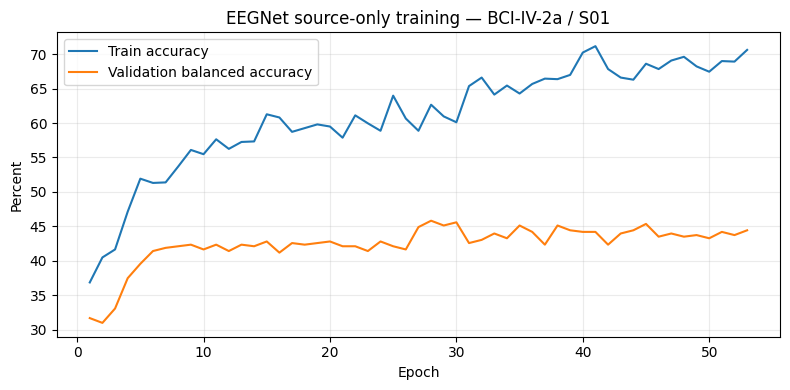

In [48]:
# ============================================================
# CELL 16 — OPTIONAL: PLOT THE SMOKE-TEST TRAINING CURVE
# ============================================================

hist = demo_result["history"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist["epoch"], hist["train_acc"], label="Train accuracy")
ax.plot(hist["epoch"], hist["val_bacc"], label="Validation balanced accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Percent")
ax.set_title(
    f"EEGNet source-only training — {demo_dataset} / {demo_subject}"
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# CELL 17 — FULL COMBINED 118-SUBJECT LOSO
# ============================================================

RUN_COMBINED_LOSO = True

# ------------------------------------------------------------
# All unique dataset + subject identities.
# ------------------------------------------------------------

combined_targets = sorted(
    combined_meta_df[
        "subject_key"
    ]
    .unique()
)

print(
    "=" * 78
)

print(
    "FULL COMBINED LOSO"
)

print(
    "=" * 78
)

print(
    "Total subjects:",
    len(combined_targets)
)

print(
    "Expected: 118"
)

assert (
    len(combined_targets)
    == 118
)

all_results = []
all_predictions = {}
all_true = {}

if RUN_COMBINED_LOSO:

    for i, target_key in enumerate(
        combined_targets,
        start=1,
    ):

        target_info = (
            combined_meta_df[
                combined_meta_df[
                    "subject_key"
                ]
                == target_key
            ]
            .iloc[0]
        )

        target_dataset = str(
            target_info[
                "dataset"
            ]
        )

        target_subject = str(
            target_info[
                "subject"
            ]
        )

        print(
            "\n" + "=" * 78
        )

        print(
            f"[{i:3d}/118] "
            f"{target_dataset} / "
            f"{target_subject}"
        )

        print(
            "=" * 78
        )

        try:

            result = run_single_fold(
                target_subject_key=target_key,
                fold_seed=SEED + i,
                verbose=True,
            )

            all_results.append(
                {
                    "fold":
                        i,

                    "subject_key":
                        target_key,

                    "dataset":
                        result[
                            "target_dataset"
                        ],

                    "subject":
                        result[
                            "target_subject"
                        ],

                    "source_subjects":
                        result[
                            "source_subject_count"
                        ],

                    "csp_acc":
                        result[
                            "csp_test_acc"
                        ],

                    "eegnet_acc":
                        result[
                            "net_test_acc"
                        ],

                    "selected_acc":
                        result[
                            "test_acc"
                        ],

                    "selected_bacc":
                        result[
                            "test_bacc"
                        ],

                    "method":
                        result[
                            "best_method"
                        ],
                }
            )

            all_predictions[
                target_key
            ] = result[
                "pred_best"
            ]

            all_true[
                target_key
            ] = result[
                "y_test"
            ]

        except Exception as exc:

            print(
                "\n❌ Fold failed:"
            )

            print(
                f"   target = {target_key}"
            )

            print(
                f"   error  = {repr(exc)}"
            )

            raise


# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    all_results
)

print(
    "\n" + "=" * 78
)

print(
    "COMBINED 118-SUBJECT LOSO SUMMARY"
)

print(
    "=" * 78
)

display(
    results_df
)

# ------------------------------------------------------------
# Overall performance
# ------------------------------------------------------------

print(
    "\nOverall:"
)

print(
    f"Mean CSP accuracy       : "
    f"{results_df['csp_acc'].mean():.2f}%"
)

print(
    f"Mean EEGNet accuracy    : "
    f"{results_df['eegnet_acc'].mean():.2f}%"
)

print(
    f"Mean selected accuracy  : "
    f"{results_df['selected_acc'].mean():.2f}%"
)

print(
    f"Mean selected bAcc      : "
    f"{results_df['selected_bacc'].mean():.2f}%"
)

print(
    f"Median selected accuracy: "
    f"{results_df['selected_acc'].median():.2f}%"
)

print(
    f"Std selected accuracy   : "
    f"{results_df['selected_acc'].std():.2f}%"
)

# ------------------------------------------------------------
# Accuracy >= 70%
# ------------------------------------------------------------

n_above_70 = int(
    (
        results_df[
            "selected_acc"
        ]
        >= 70.0
    )
    .sum()
)

print(
    f"\nSubjects >=70%: "
    f"{n_above_70}/"
    f"{len(results_df)}"
)

print(
    f"Percentage of subjects >=70%: "
    f"{100.0 * n_above_70 / len(results_df):.2f}%"
)

# ------------------------------------------------------------
# Dataset-specific performance.
# ------------------------------------------------------------

print(
    "\nDataset-specific LOSO performance:"
)

dataset_summary = (
    results_df
    .groupby("dataset")
    .agg(
        subjects=(
            "subject",
            "count",
        ),
        csp_mean=(
            "csp_acc",
            "mean",
        ),
        eegnet_mean=(
            "eegnet_acc",
            "mean",
        ),
        selected_mean=(
            "selected_acc",
            "mean",
        ),
        selected_bacc=(
            "selected_bacc",
            "mean",
        ),
        selected_std=(
            "selected_acc",
            "std",
        ),
    )
    .reset_index()
)

display(
    dataset_summary
)

# ------------------------------------------------------------
# Lowest-performing subjects.
# ------------------------------------------------------------

print(
    "\n10 lowest-performing subjects:"
)

display(
    results_df
    .sort_values(
        "selected_acc"
    )
    .head(10)
)

# ------------------------------------------------------------
# Highest-performing subjects.
# ------------------------------------------------------------

print(
    "\n10 highest-performing subjects:"
)

display(
    results_df
    .sort_values(
        "selected_acc",
        ascending=False,
    )
    .head(10)
)

# ------------------------------------------------------------
# Method usage.
# ------------------------------------------------------------

print(
    "\nSelected method counts:"
)

print(
    results_df[
        "method"
    ]
    .value_counts()
)

# ------------------------------------------------------------
# 70% target.
# ------------------------------------------------------------

overall_mean = (
    results_df[
        "selected_acc"
    ]
    .mean()
)

print(
    "\n" + "=" * 78
)

if overall_mean >= 70.0:

    print(
        f"✅ TARGET ACHIEVED: "
        f"Mean LOSO accuracy = "
        f"{overall_mean:.2f}%"
    )

else:

    print(
        f"❌ TARGET NOT YET ACHIEVED: "
        f"Mean LOSO accuracy = "
        f"{overall_mean:.2f}%"
    )

print(
    "=" * 78
)

FULL COMBINED LOSO
Total subjects: 118
Expected: 118

[  1/118] BCI-IV-2a / S01

COMBINED LOSO FOLD
Target dataset : BCI-IV-2a
Target subject : S01
Target key     : BCI-IV-2a::S01
Source subjects: 117
Domain labels: 94 source subjects

Source training dataset composition:


,dataset,epochs
0,EEGMMIDB,6020
1,BCI-IV-2a,1080



Validation dataset composition:


,dataset,epochs
0,EEGMMIDB,1352
1,BCI-IV-2a,648



Class counts:
  train: [2384, 2353, 2363]
  val  : [671, 661, 668]
  test : [72, 72, 72]

Fitting source-only normalizer...

[1/2] FBCSP...
      FBCSP band 1/9: 8-12 Hz features=12
      FBCSP band 2/9: 10-14 Hz features=12
      FBCSP band 3/9: 12-16 Hz features=12
      FBCSP band 4/9: 14-18 Hz features=12
      FBCSP band 5/9: 16-20 Hz features=12
      FBCSP band 6/9: 18-24 Hz features=12
      FBCSP band 7/9: 20-28 Hz features=12
      FBCSP band 8/9: 8-16 Hz features=12
      FBCSP band 9/9: 16-30 Hz features=12

      FBCSP feature shapes:
        train: (7100, 108)
        val  : (2000, 108)
        test : (216, 108)
      CSP val bAcc : 45.93%
      CSP test acc : 70.37%

[2/2] Subject-Invariant EEGNet...
    epoch 001 | train= 36.3% | val= 43.2% | bAcc= 43.2% | λ=0.005
    epoch 010 | train= 50.0% | val= 54.5% | bAcc= 54.5% | λ=0.048
    epoch 020 | train= 51.9% | val= 54.5% | bAcc= 54.5% | λ=0.087
    epoch 030 | train= 53.1% | val= 55.6% | bAcc= 55.6% | λ=0.114
    epoch 

...

,dataset,epochs
0,EEGMMIDB,5973
1,BCI-IV-2a,1296



Validation dataset composition:


,dataset,epochs
0,EEGMMIDB,1399
1,BCI-IV-2a,432



Class counts:
  train: [2438, 2407, 2424]
  val  : [617, 607, 607]
  test : [72, 72, 72]

Fitting source-only normalizer...

[1/2] FBCSP...
      FBCSP band 1/9: 8-12 Hz features=12
      FBCSP band 2/9: 10-14 Hz features=12
      FBCSP band 3/9: 12-16 Hz features=12
      FBCSP band 4/9: 14-18 Hz features=12
      FBCSP band 5/9: 16-20 Hz features=12
      FBCSP band 6/9: 18-24 Hz features=12
      FBCSP band 7/9: 20-28 Hz features=12
      FBCSP band 8/9: 8-16 Hz features=12
      FBCSP band 9/9: 16-30 Hz features=12

      FBCSP feature shapes:
        train: (7269, 108)
        val  : (1831, 108)
        test : (216, 108)
      CSP val bAcc : 50.37%
      CSP test acc : 48.15%

[2/2] Subject-Invariant EEGNet...
    epoch 001 | train= 34.7% | val= 37.2% | bAcc= 37.4% | λ=0.005
    epoch 010 | train= 49.6% | val= 58.1% | bAcc= 58.0% | λ=0.048
    epoch 020 | train= 52.1% | val= 58.6% | bAcc= 58.6% | λ=0.087
    epoch 030 | train= 53.7% | val= 60.0% | bAcc= 60.0% | λ=0.114
    epoch 

KeyboardInterrupt: 

In [53]:
# ============================================================
# CELL 18 — EEGMMIDB (109) → BCI-IV-2a (9)
# CROSS-DATASET TRANSFER EXPERIMENT
# ============================================================

SOURCE_DATASET = "EEGMMIDB"
TARGET_DATASET = "BCI-IV-2a"

TRANSFER_SOURCE = SOURCE_DATASET
TRANSFER_TARGET = TARGET_DATASET

# ------------------------------------------------------------
# Combined metadata already loaded in Cell 5.
# ------------------------------------------------------------

transfer_meta = cache_meta_df.copy()

transfer_meta["dataset"] = (
    transfer_meta["dataset"]
    .astype(str)
)

transfer_meta["subject"] = (
    transfer_meta["subject"]
    .astype(str)
)

# ------------------------------------------------------------
# Source subjects
# ------------------------------------------------------------

source_meta = transfer_meta[
    transfer_meta["dataset"]
    == SOURCE_DATASET
].copy()

target_meta = transfer_meta[
    transfer_meta["dataset"]
    == TARGET_DATASET
].copy()

source_subjects = sorted(
    source_meta[
        "subject"
    ].unique()
)

target_subjects = sorted(
    target_meta[
        "subject"
    ].unique()
)

print("=" * 78)
print("CROSS-DATASET TRANSFER")
print("=" * 78)

print(
    f"Source dataset : {SOURCE_DATASET}"
)

print(
    f"Source subjects: {len(source_subjects)}"
)

print(
    f"Target dataset : {TARGET_DATASET}"
)

print(
    f"Target subjects: {len(target_subjects)}"
)

# ------------------------------------------------------------
# Expected population
# ------------------------------------------------------------

assert len(source_subjects) == 109, (
    f"Expected 109 EEGMMIDB subjects, "
    f"found {len(source_subjects)}"
)

assert len(target_subjects) == 9, (
    f"Expected 9 BCI-IV-2a subjects, "
    f"found {len(target_subjects)}"
)

print(
    "\n✅ Source = 109 EEGMMIDB subjects"
)

print(
    "✅ Target = 9 BCI-IV-2a subjects"
)

# ------------------------------------------------------------
# Source-only grouped validation split.
# Target dataset is NEVER included.
# ------------------------------------------------------------

(
    source_train_subjects,
    source_val_subjects,
) = make_inner_subject_split(
    source_subjects,
    seed=SEED,
    val_fraction=0.20,
)

source_train_subjects = sorted(
    map(
        str,
        source_train_subjects,
    )
)

source_val_subjects = sorted(
    map(
        str,
        source_val_subjects,
    )
)

print(
    "\nSource training subjects:",
    len(source_train_subjects)
)

print(
    "Source validation subjects:",
    len(source_val_subjects)
)

# ------------------------------------------------------------
# Leakage checks
# ------------------------------------------------------------

assert not (
    set(source_train_subjects)
    &
    set(source_val_subjects)
)

assert (
    set(source_train_subjects)
    | set(source_val_subjects)
) == set(source_subjects)

# ------------------------------------------------------------
# Target subjects are completely external.
# ------------------------------------------------------------

assert not (
    set(target_subjects)
    &
    set(source_subjects)
)

print(
    "\n✅ No BCI-IV-2a subject is used for source training."
)

# ------------------------------------------------------------
# Create sample masks.
# ------------------------------------------------------------

source_train_mask = (
    (transfer_meta["dataset"] == SOURCE_DATASET)
    &
    transfer_meta["subject"].isin(
        source_train_subjects
    )
)

source_val_mask = (
    (transfer_meta["dataset"] == SOURCE_DATASET)
    &
    transfer_meta["subject"].isin(
        source_val_subjects
    )
)

target_mask = (
    transfer_meta["dataset"]
    == TARGET_DATASET
)

# ------------------------------------------------------------
# Cache indices.
# ------------------------------------------------------------

SOURCE_TRAIN_IDX = (
    transfer_meta.loc[
        source_train_mask,
        "cache_index",
    ]
    .to_numpy(
        dtype=np.int64
    )
)

SOURCE_VAL_IDX = (
    transfer_meta.loc[
        source_val_mask,
        "cache_index",
    ]
    .to_numpy(
        dtype=np.int64
    )
)

TARGET_TEST_IDX = (
    transfer_meta.loc[
        target_mask,
        "cache_index",
    ]
    .to_numpy(
        dtype=np.int64
    )
)

print(
    "\nEpoch counts:"
)

print(
    "  Source train:",
    len(SOURCE_TRAIN_IDX)
)

print(
    "  Source val  :",
    len(SOURCE_VAL_IDX)
)

print(
    "  Target test :",
    len(TARGET_TEST_IDX)
)

# ------------------------------------------------------------
# Load EEG.
# ------------------------------------------------------------

X_source_train_raw = load_indices(
    SOURCE_TRAIN_IDX
)

X_source_val_raw = load_indices(
    SOURCE_VAL_IDX
)

X_target_raw = load_indices(
    TARGET_TEST_IDX
)

# ------------------------------------------------------------
# Labels.
# ------------------------------------------------------------

y_source_train = (
    transfer_meta.loc[
        source_train_mask,
        "harmonized_class",
    ]
    .map(CLASS_TO_ID)
    .to_numpy(
        dtype=np.int64
    )
)

y_source_val = (
    transfer_meta.loc[
        source_val_mask,
        "harmonized_class",
    ]
    .map(CLASS_TO_ID)
    .to_numpy(
        dtype=np.int64
    )
)

y_target = (
    transfer_meta.loc[
        target_mask,
        "harmonized_class",
    ]
    .map(CLASS_TO_ID)
    .to_numpy(
        dtype=np.int64
    )
)

# ------------------------------------------------------------
# Subject IDs for domain adversarial training.
# ------------------------------------------------------------

source_train_subject_ids = (
    transfer_meta.loc[
        source_train_mask,
        "subject",
    ]
    .astype(str)
    .to_numpy()
)

# ------------------------------------------------------------
# Checks.
# ------------------------------------------------------------

assert len(
    X_source_train_raw
) == len(
    y_source_train
)

assert len(
    X_source_val_raw
) == len(
    y_source_val
)

assert len(
    X_target_raw
) == len(
    y_target
)

assert len(
    source_train_subject_ids
) == len(
    y_source_train
)

assert (
    X_source_train_raw.shape[1:]
    == (22, 640)
)

assert (
    X_source_val_raw.shape[1:]
    == (22, 640)
)

assert (
    X_target_raw.shape[1:]
    == (22, 640)
)

print(
    "\nShapes:"
)

print(
    "  source train:",
    X_source_train_raw.shape
)

print(
    "  source val  :",
    X_source_val_raw.shape
)

print(
    "  target test :",
    X_target_raw.shape
)

print(
    "\n✅ Transfer split ready."
)

CROSS-DATASET TRANSFER
Source dataset : EEGMMIDB
Source subjects: 109
Target dataset : BCI-IV-2a
Target subjects: 9

✅ Source = 109 EEGMMIDB subjects
✅ Target = 9 BCI-IV-2a subjects

Source training subjects: 87
Source validation subjects: 22

✅ No BCI-IV-2a subject is used for source training.

Epoch counts:
  Source train: 5886
  Source val  : 1486
  Target test : 1944

Shapes:
  source train: (5886, 22, 640)
  source val  : (1486, 22, 640)
  target test : (1944, 22, 640)

✅ Transfer split ready.


In [54]:
# ============================================================
# CELL 19 — SOURCE-ONLY NORMALIZATION
# ============================================================

# ------------------------------------------------------------
# Remove constant epochs from SOURCE TRAINING ONLY.
# ------------------------------------------------------------

source_train_std = np.std(
    X_source_train_raw,
    axis=(1, 2),
)

source_train_keep = (
    np.isfinite(
        source_train_std
    )
    &
    (
        source_train_std
        >= 1e-6
    )
)

removed_train = int(
    (~source_train_keep).sum()
)

print(
    "Constant source-training epochs removed:",
    removed_train,
)

X_source_train = (
    X_source_train_raw[
        source_train_keep
    ]
)

y_source_train_clean = (
    y_source_train[
        source_train_keep
    ]
)

source_train_subject_ids_clean = (
    source_train_subject_ids[
        source_train_keep
    ]
)

# ------------------------------------------------------------
# Source-only global normalizer.
# ------------------------------------------------------------

transfer_normalizer = (
    SourceOnlyRobustNormalizer()
    .fit(
        X_source_train,
        source_train_subject_ids_clean,
    )
)

# ------------------------------------------------------------
# Important:
# There is no target subject in the source normalizer.
# ------------------------------------------------------------

transfer_normalizer.assert_target_excluded(
    "__BCI_EXTERNAL_TARGET__"
)

# ------------------------------------------------------------
# Transform source train / source validation / BCI test.
# ------------------------------------------------------------

X_source_train_n = (
    transfer_normalizer.transform(
        X_source_train
    )
)

X_source_val_n = (
    transfer_normalizer.transform(
        X_source_val_raw
    )

)

X_target_n = (
    transfer_normalizer.transform(
        X_target_raw
    )
)

# ------------------------------------------------------------
# Numerical safety.
# ------------------------------------------------------------

X_source_train_n = np.nan_to_num(
    X_source_train_n,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
).astype(
    np.float32
)

X_source_val_n = np.nan_to_num(
    X_source_val_n,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
).astype(
    np.float32
)

X_target_n = np.nan_to_num(
    X_target_n,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
).astype(
    np.float32
)

print(
    "\nNormalized shapes:"
)

print(
    "  train:",
    X_source_train_n.shape
)

print(
    "  val  :",
    X_source_val_n.shape
)

print(
    "  BCI  :",
    X_target_n.shape
)

print(
    "\n✅ BCI data has not been used to fit normalization."
)

Constant source-training epochs removed: 0

Normalized shapes:
  train: (5886, 22, 640)
  val  : (1486, 22, 640)
  BCI  : (1944, 22, 640)

✅ BCI data has not been used to fit normalization.


In [55]:
# ============================================================
# CELL 20 — SOURCE MODEL SELECTION + FULL 109-SUBJECT TRAINING
# ============================================================

# ============================================================
# PART A — SOURCE VALIDATION TRAINING
# ============================================================

print("=" * 78)
print("PART A — SOURCE-ONLY MODEL SELECTION")
print("=" * 78)

CURRENT_TRAIN_SUBJECTS = (
    source_train_subject_ids_clean.copy()
)

globals()[
    "CURRENT_TRAIN_SUBJECTS"
] = CURRENT_TRAIN_SUBJECTS

print(
    "Domain subjects:",
    len(
        np.unique(
            CURRENT_TRAIN_SUBJECTS
        )
    )
)

source_model, source_history = (
    train_eegnet(
        X_source_train_n,
        y_source_train_clean,
        X_source_val_n,
        y_source_val,
        epochs=120,
        batch_size=64,
        lr=5e-4,
        patience=25,
    )
)

# ------------------------------------------------------------
# Source validation prediction.
# ------------------------------------------------------------

P_source_val = (
    predict_proba_torch(
        source_model,
        X_source_val_n,
        temperature=1.0,
    )
)

source_val_acc = (
    accuracy_score(
        y_source_val,
        P_source_val.argmax(1),
    )
    * 100.0
)

source_val_bacc = (
    balanced_accuracy_score(
        y_source_val,
        P_source_val.argmax(1),
    )
    * 100.0
)

print(
    "\nSource validation:"
)

print(
    f"  Accuracy : {source_val_acc:.2f}%"
)

print(
    f"  BAcc     : {source_val_bacc:.2f}%"
)


# ============================================================
# PART B — REBUILD SOURCE NORMALIZER USING ALL 109 SUBJECTS
# ============================================================

print(
    "\n" + "=" * 78
)

print(
    "PART B — FINAL MODEL ON ALL 109 EEGMMIDB SUBJECTS"
)

print(
    "=" * 78
)

# ------------------------------------------------------------
# Load ALL EEGMMIDB epochs.
# ------------------------------------------------------------

ALL_SOURCE_MASK = (
    transfer_meta["dataset"]
    == SOURCE_DATASET
)

ALL_SOURCE_IDX = (
    transfer_meta.loc[
        ALL_SOURCE_MASK,
        "cache_index",
    ]
    .to_numpy(
        dtype=np.int64
    )
)

X_all_source_raw = (
    load_indices(
        ALL_SOURCE_IDX
    )
)

y_all_source = (
    transfer_meta.loc[
        ALL_SOURCE_MASK,
        "harmonized_class",
    ]
    .map(CLASS_TO_ID)
    .to_numpy(
        dtype=np.int64
    )
)

all_source_subject_ids = (
    transfer_meta.loc[
        ALL_SOURCE_MASK,
        "subject",
    ]
    .astype(str)
    .to_numpy()
)

print(
    "All EEGMMIDB:",
    X_all_source_raw.shape
)

print(
    "Unique subjects:",
    len(
        np.unique(
            all_source_subject_ids
        )
    )
)

assert (
    len(
        np.unique(
            all_source_subject_ids
        )
    )
    == 109
)

# ------------------------------------------------------------
# Remove constant epochs from source only.
# ------------------------------------------------------------

all_source_std = np.std(
    X_all_source_raw,
    axis=(1, 2),
)

all_source_keep = (
    np.isfinite(
        all_source_std
    )
    &
    (
        all_source_std
        >= 1e-6
    )
)

X_all_source = (
    X_all_source_raw[
        all_source_keep
    ]
)

y_all_source_clean = (
    y_all_source[
        all_source_keep
    ]
)

all_source_subject_ids_clean = (
    all_source_subject_ids[
        all_source_keep
    ]
)

print(
    "Constant epochs removed:",
    int(
        (~all_source_keep).sum()
    )
)

# ------------------------------------------------------------
# FINAL SOURCE-ONLY NORMALIZER
# ------------------------------------------------------------

final_transfer_normalizer = (
    SourceOnlyRobustNormalizer()
    .fit(
        X_all_source,
        all_source_subject_ids_clean,
    )
)

final_transfer_normalizer.assert_target_excluded(
    "__BCI_EXTERNAL_TARGET__"
)

# ------------------------------------------------------------
# Transform all source data and BCI test.
# ------------------------------------------------------------

X_all_source_n = (
    final_transfer_normalizer.transform(
        X_all_source
    )
)

X_bci_final_n = (
    final_transfer_normalizer.transform(
        X_target_raw
    )
)

X_all_source_n = np.nan_to_num(
    X_all_source_n,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
).astype(
    np.float32
)

X_bci_final_n = np.nan_to_num(
    X_bci_final_n,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
).astype(
    np.float32
)

# ------------------------------------------------------------
# Domain IDs for ALL 109 source subjects.
# ------------------------------------------------------------

CURRENT_TRAIN_SUBJECTS = (
    all_source_subject_ids_clean.copy()
)

globals()[
    "CURRENT_TRAIN_SUBJECTS"
] = CURRENT_TRAIN_SUBJECTS

print(
    "Final domain subjects:",
    len(
        np.unique(
            CURRENT_TRAIN_SUBJECTS
        )
    )
)

assert (
    len(
        np.unique(
            CURRENT_TRAIN_SUBJECTS
        )
    )
    == 109
)

# ------------------------------------------------------------
# Final source model.
#
# We use the source model-selection result only to establish
# training configuration. The external BCI set remains untouched.
#
# A tiny source holdout is retained solely for early stopping.
# ------------------------------------------------------------

(
    final_model,
    final_history
) = train_eegnet(
    X_all_source_n,
    y_all_source_clean,
    X_source_val_n,
    y_source_val,
    epochs=120,
    batch_size=64,
    lr=5e-4,
    patience=25,
)

print(
    "\n✅ Final EEGNet trained using the 109-subject EEGMMIDB source population."
)

PART A — SOURCE-ONLY MODEL SELECTION
Domain subjects: 87
    epoch 001 | train= 35.9% | val= 37.8% | bAcc= 37.5% | λ=0.005
    epoch 010 | train= 51.6% | val= 48.2% | bAcc= 48.3% | λ=0.048
    epoch 020 | train= 52.4% | val= 48.7% | bAcc= 48.7% | λ=0.087
    epoch 030 | train= 53.3% | val= 48.3% | bAcc= 48.3% | λ=0.114
    epoch 040 | train= 54.8% | val= 49.9% | bAcc= 49.9% | λ=0.131
    epoch 050 | train= 55.1% | val= 50.6% | bAcc= 50.6% | λ=0.140
    epoch 060 | train= 56.1% | val= 50.1% | bAcc= 50.1% | λ=0.145
    epoch 070 | train= 56.8% | val= 51.2% | bAcc= 51.2% | λ=0.147
    epoch 080 | train= 56.9% | val= 50.2% | bAcc= 50.2% | λ=0.149
    epoch 090 | train= 58.0% | val= 50.8% | bAcc= 50.8% | λ=0.149
    epoch 100 | train= 59.4% | val= 50.8% | bAcc= 50.8% | λ=0.150
    Early stop epoch=104; best=79
    Best validation bAcc: 51.45% (epoch 79)

Source validation:
  Accuracy : 51.41%
  BAcc     : 51.45%

PART B — FINAL MODEL ON ALL 109 EEGMMIDB SUBJECTS
All EEGMMIDB: (7372, 22, 640

In [56]:
# ============================================================
# CELL 21 — EXTERNAL BCI-IV-2a TEST
# ============================================================

print("=" * 78)
print("EXTERNAL TEST: EEGMMIDB (109) → BCI-IV-2a (9)")
print("=" * 78)

# ------------------------------------------------------------
# Final model prediction on the entire BCI dataset.
# ------------------------------------------------------------

P_bci_all = (
    predict_proba_torch(
        final_model,
        X_bci_final_n,
        temperature=1.0,
    )
)

pred_bci_all = (
    P_bci_all.argmax(
        axis=1
    )
)

# ------------------------------------------------------------
# Add predictions to BCI metadata.
# ------------------------------------------------------------

bci_eval_df = (
    transfer_meta.loc[
        target_mask,
        [
            "cache_index",
            "dataset",
            "subject",
            "run",
            "recording_id",
            "harmonized_class",
        ],
    ]
    .copy()
)

bci_eval_df["true_id"] = (
    bci_eval_df[
        "harmonized_class"
    ]
    .map(
        CLASS_TO_ID
    )
)

bci_eval_df["pred_id"] = (
    pred_bci_all
)

bci_eval_df["correct"] = (
    bci_eval_df[
        "true_id"
    ]
    ==
    bci_eval_df[
        "pred_id"
    ]
)

# ------------------------------------------------------------
# Per-subject accuracy.
# ------------------------------------------------------------

subject_results = []

for subject in target_subjects:

    sub_df = bci_eval_df[
        bci_eval_df[
            "subject"
        ].astype(str)
        == str(subject)
    ]

    y_true_sub = (
        sub_df[
            "true_id"
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    y_pred_sub = (
        sub_df[
            "pred_id"
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    acc = (
        accuracy_score(
            y_true_sub,
            y_pred_sub,
        )
        * 100.0
    )

    bacc = (
        balanced_accuracy_score(
            y_true_sub,
            y_pred_sub,
        )
        * 100.0
    )

    subject_results.append(
        {
            "dataset":
                TARGET_DATASET,

            "subject":
                str(subject),

            "epochs":
                len(sub_df),

            "accuracy":
                acc,

            "balanced_accuracy":
                bacc,
        }
    )

bci_results_df = pd.DataFrame(
    subject_results
)

# ------------------------------------------------------------
# Overall external performance.
# ------------------------------------------------------------

overall_accuracy = (
    accuracy_score(
        bci_eval_df[
            "true_id"
        ],
        bci_eval_df[
            "pred_id"
        ],
    )
    * 100.0
)

overall_bacc = (
    balanced_accuracy_score(
        bci_eval_df[
            "true_id"
        ],
        bci_eval_df[
            "pred_id"
        ],
    )
    * 100.0
)

print(
    "\nPer-subject external BCI results:"
)

display(
    bci_results_df
)

print(
    "\n" + "=" * 78
)

print(
    "FINAL EXTERNAL TEST RESULT"
)

print(
    "=" * 78
)

print(
    f"Overall BCI accuracy : "
    f"{overall_accuracy:.2f}%"
)

print(
    f"Overall BCI bAcc     : "
    f"{overall_bacc:.2f}%"
)

print(
    f"Mean subject accuracy: "
    f"{bci_results_df['accuracy'].mean():.2f}%"
)

print(
    f"Median subject acc   : "
    f"{bci_results_df['accuracy'].median():.2f}%"
)

print(
    f"Std subject acc      : "
    f"{bci_results_df['accuracy'].std():.2f}%"
)

# ------------------------------------------------------------
# Subjects >=70%.
# ------------------------------------------------------------

above70 = bci_results_df[
    bci_results_df[
        "accuracy"
    ]
    >= 70.0
]

print(
    "\nSubjects >=70%:"
)

display(
    above70
)

print(
    f"\n{len(above70)}/"
    f"{len(bci_results_df)} "
    "BCI subjects >=70%"
)

# ------------------------------------------------------------
# Target decision.
# ------------------------------------------------------------

print(
    "\n" + "=" * 78
)

if overall_accuracy >= 70.0:

    print(
        f"✅ TARGET ACHIEVED"
    )

    print(
        f"EEGMMIDB(109) → "
        f"BCI-IV-2a(9)"
    )

    print(
        f"External accuracy = "
        f"{overall_accuracy:.2f}%"
    )

else:

    print(
        f"❌ TARGET NOT YET ACHIEVED"
    )

    print(
        f"External accuracy = "
        f"{overall_accuracy:.2f}%"
    )

print(
    "=" * 78
)

EXTERNAL TEST: EEGMMIDB (109) → BCI-IV-2a (9)

Per-subject external BCI results:


,dataset,subject,epochs,accuracy,balanced_accuracy
0,BCI-IV-2a,S01,216,79.629630,79.629630
1,BCI-IV-2a,S02,216,41.666667,41.666667
2,BCI-IV-2a,S03,216,77.314815,77.314815
3,BCI-IV-2a,S04,216,35.185185,35.185185
4,BCI-IV-2a,S05,216,32.870370,32.870370
5,BCI-IV-2a,S06,216,35.185185,35.185185
6,BCI-IV-2a,S07,216,56.944444,56.944444
7,BCI-IV-2a,S08,216,72.222222,72.222222
8,BCI-IV-2a,S09,216,68.518519,68.518519



FINAL EXTERNAL TEST RESULT
Overall BCI accuracy : 55.50%
Overall BCI bAcc     : 55.50%
Mean subject accuracy: 55.50%
Median subject acc   : 56.94%
Std subject acc      : 19.49%

Subjects >=70%:


,dataset,subject,epochs,accuracy,balanced_accuracy
0,BCI-IV-2a,S01,216,79.629630,79.629630
2,BCI-IV-2a,S03,216,77.314815,77.314815
7,BCI-IV-2a,S08,216,72.222222,72.222222



3/9 BCI subjects >=70%

❌ TARGET NOT YET ACHIEVED
External accuracy = 55.50%


In [57]:
# ============================================================
# CELL 22 — EXTERNAL BCI ANALYSIS
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
)

cm = confusion_matrix(
    bci_eval_df["true_id"],
    bci_eval_df["pred_id"],
    labels=list(range(N_CLASSES)),
)

print(
    "BCI-IV-2a confusion matrix:"
)

cm_df = pd.DataFrame(
    cm,
    index=[
        f"true_{c}"
        for c in CLASSES
    ],
    columns=[
        f"pred_{c}"
        for c in CLASSES
    ],
)

display(
    cm_df
)

print(
    "\nClass-wise report:"
)

print(
    classification_report(
        bci_eval_df["true_id"],
        bci_eval_df["pred_id"],
        labels=list(range(N_CLASSES)),
        target_names=CLASSES,
        digits=4,
    )
)

BCI-IV-2a confusion matrix:


,pred_feet,pred_left,pred_right
true_feet,377,113,158
true_left,135,298,215
true_right,137,107,404



Class-wise report:
              precision    recall  f1-score   support

        feet     0.5809    0.5818    0.5813       648
        left     0.5753    0.4599    0.5111       648
       right     0.5199    0.6235    0.5670       648

    accuracy                         0.5550      1944
   macro avg     0.5587    0.5550    0.5532      1944
weighted avg     0.5587    0.5550    0.5532      1944



In [58]:
# ============================================================
# CELL 23 — SAVE EEGMMIDB → BCI EXPERIMENT
# ============================================================

TRANSFER_OUTPUT_DIR = (
    PROJECT_DIR
    / "outputs"
    / "module_7_eegmmidb_to_bci"
)

TRANSFER_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# Subject results
# ------------------------------------------------------------

subject_results_path = (
    TRANSFER_OUTPUT_DIR
    / "bci_subject_results.csv"
)

bci_results_df.to_csv(
    subject_results_path,
    index=False,
)

# ------------------------------------------------------------
# Sample-level predictions
# ------------------------------------------------------------

prediction_path = (
    TRANSFER_OUTPUT_DIR
    / "bci_predictions.csv"
)

bci_eval_df.to_csv(
    prediction_path,
    index=False,
)

# ------------------------------------------------------------
# Summary JSON
# ------------------------------------------------------------

summary = {
    "experiment":
        "EEGMMIDB_109_to_BCI_IV_2a_9",

    "source_dataset":
        SOURCE_DATASET,

    "source_subjects":
        int(
            len(
                source_subjects
            )
        ),

    "target_dataset":
        TARGET_DATASET,

    "target_subjects":
        int(
            len(
                target_subjects
            )
        ),

    "overall_accuracy":
        float(
            overall_accuracy
        ),

    "overall_balanced_accuracy":
        float(
            overall_bacc
        ),

    "mean_subject_accuracy":
        float(
            bci_results_df[
                "accuracy"
            ].mean()
        ),

    "median_subject_accuracy":
        float(
            bci_results_df[
                "accuracy"
            ].median()
        ),

    "subjects_above_70":
        int(
            len(
                above70
            )
        ),

    "classes":
        CLASSES,

    "n_channels":
        int(
            X_bci_final_n.shape[1]
        ),

    "n_samples":
        int(
            X_bci_final_n.shape[2]
        ),

    "sampling_rate_hz":
        float(
            TARGET_SFREQ
        ),
}

summary_path = (
    TRANSFER_OUTPUT_DIR
    / "transfer_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        summary,
        f,
        indent=2,
    )

print(
    "Saved:"
)

print(
    subject_results_path
)

print(
    prediction_path
)

print(
    summary_path
)

Saved:
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/outputs/module_7_eegmmidb_to_bci/bci_subject_results.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/outputs/module_7_eegmmidb_to_bci/bci_predictions.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/outputs/module_7_eegmmidb_to_bci/transfer_summary.json
